# Networks of persons in relation to organisations


Cf. [this notebook](https://github.com/Sciences-historiques-numeriques/histoire_numerique_methodes/blob/main/analyse_reseaux/reseaux_florence.ipynb) about families and power in Renaissance Florence for an introduction to network analysis with the *networkx* Python library



In [124]:
import pandas as pd


import networkx as nx
from networkx.algorithms import bipartite

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MaxNLocator

from scipy.stats import spearmanr
import statsmodels.api as sm

import numpy as np
import seaborn as sns
import math
import os

In [3]:
### this library allows to do SQL queries on dataframes
import duckdb

In [4]:
### Librairies déjà installées avec Python
import pprint
import csv

import sqlite3 as sql
import pickle

import time
import datetime
from dateutil import parser


from shutil import copyfile


In [5]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

import sys
from importlib import reload

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [6]:

import network_analysis_functions as naf
import bivariate_library as bl

In [7]:
print(reload(naf))  

<module 'network_analysis_functions' from '/home/francesco/kDrive/python_notebooks/astronomers/notebooks_jupyter/wikidata_exploration/../network_analysis_functions.py'>


In [8]:
import warnings
warnings.filterwarnings('ignore')


## Get and inspect the data


We use in this notebook the network data prepared in these two files:
* Get the [relationships with SPARQL](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da6-person-organisation-network.md)
* Prepare the [SQL view and export the data to CSV](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da6-person-organisation-network.sql)


Regarding persons, we reuse the file with the persons, their periods of activity and coded countries, that we created in the correspondence analysis chapter.




#### Get the network data

In [9]:
### Import information about relations to organisations - df_po

csv_address='da_data/da6-persons-organisations-relations.csv'
df_po = pd.read_csv(csv_address)
df_po.head(3)

,person_uri,organisation_uri,organisation_label,relationship
0,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q153978,University of Tübingen,education
1,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q543804,German Academy of Sciences Leopoldina,membership
2,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q833738,Heidelberg Academy of Sciences and Humanities,membership


In [10]:
### Inspect the dataframe and 
# notably if there are missing values
df_po.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80676 entries, 0 to 80675
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   person_uri          80676 non-null  object
 1   organisation_uri    80676 non-null  object
 2   organisation_label  80676 non-null  object
 3   relationship        80676 non-null  object
dtypes: object(4)
memory usage: 2.5+ MB


In [11]:
### Number of types of relationships
df_rela_type=pd.DataFrame(df_po.groupby(by='relationship').size())
df_rela_type.columns=['number']
df_rela_type

,number
relationship,
education,29936
employment,32262
membership,18478


#### Get the data about persons

In [12]:
### Information about persons with gender, birth date,
# coded country, etc.
csv_address='da_data/da4-AFC.csv'
### csv_address='da_data/da2-birth-place.csv'
df_p = pd.read_csv(csv_address)
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,France,1831,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,Germany,1827,1826-1850
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.033056 48.139722),http://www.wikidata.org/entity/Q752334,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1834,1826-1850


In [13]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20043 entries, 0 to 20042
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   uriPer           20043 non-null  object
 1   labelPer         20043 non-null  object
 2   birthYear        20043 non-null  int64 
 3   gender           20043 non-null  object
 4   labelPlace       20043 non-null  object
 5   geometry         20043 non-null  object
 6   uriPlace         20043 non-null  object
 7   periods          20043 non-null  object
 8   FID              20043 non-null  int64 
 9   REGION           20043 non-null  object
 10  CNTR_ID          20043 non-null  object
 11  CNTR_NAME        20043 non-null  object
 12  NAME_ENGL        20043 non-null  object
 13  ISO3_CODE        20043 non-null  object
 14  coded_country    20043 non-null  object
 15  activityYear     20043 non-null  int64 
 16  periodsActivity  20043 non-null  object
dtypes: int64(3), object(14)
memory 

#### Writing SQL queries with the duckdb library

In [14]:
### Distribution of coded countries
dfc=pd.DataFrame(df_p.groupby(by=['coded_country']).size())
dfc.sort_values(by=0,ascending=False)


,0
coded_country,
Germany,3158
United States Can.,2769
Russian Federation,2458
Italy,1128
United Kingdom,1120
France,1115
Czechia,1005
Poland,990
Austria Hungary,875


In [32]:
### Distribution of coded countries
dfc=duckdb.query("""
    SELECT coded_country, COUNT(*) as num
    FROM df_p
    GROUP BY coded_country
    ORDER BY num DESC
  """).to_df()
dfc

,coded_country,num
0,Germany,3158
1,United States Can.,2769
2,Russian Federation,2458
3,Italy,1128
4,United Kingdom,1120
5,France,1115
6,Czechia,1005
7,Poland,990
8,Austria Hungary,875
9,Baltic States Fin. Belar.,866


### Merge the two dataframes

This will restrict the information about relations to the persons that are present in the *da4-AFC.csv* file, i.e. only those with coded countries

In [15]:
df_p=df_p[['uriPer', 'labelPer', 'gender', 'birthYear','coded_country', 'periodsActivity']]
df_p=df_p.rename(columns={'uriPer':'person_uri'})
df_p.head(3)

,person_uri,labelPer,gender,birthYear,coded_country,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,male,1786,France,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,male,1782,Germany,1826-1850
2,http://www.wikidata.org/entity/Q874465,József Csorba,male,1789,Ukraine,1826-1850


In [16]:
### Merge the two dataframes:
# only relations that involve persons in df_p
# will remain
df_rel=df_p.merge(df_po,on='person_uri')


In [17]:
print(len(df_rel))
df_rel.head(2)

58358


,person_uri,labelPer,gender,birthYear,coded_country,periodsActivity,organisation_uri,organisation_label,relationship
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,male,1786,France,1826-1850,http://www.wikidata.org/entity/Q1049334,United States Army Corps of Engineers,employment
1,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,male,1786,France,1826-1850,http://www.wikidata.org/entity/Q21708235,Collège Louis-le-Grand (Paris),employment


In [18]:
### Number of types of relationships
df_rela_type=pd.DataFrame(df_rel.groupby(by='relationship').size())
df_rela_type.columns=['number']
df_rela_type

,number
relationship,
education,20843
employment,22636
membership,14879


In [19]:
### Number of persons
print(f"Number of persons with relations: {len(df_rel['person_uri'].unique())}")


Number of persons with relations: 16416


In [47]:
### Count number of relations per person
df_pn=pd.DataFrame(df_rel.groupby(by='person_uri').size().sort_values(ascending=False))
df_pn.columns=['number']
### Merge for inspection
df_pp=df_pn.merge(df_p, left_index=True, right_on='person_uri')
df_pp.iloc[:10]

,number,person_uri,labelPer,gender,birthYear,coded_country,periodsActivity
2782,37,http://www.wikidata.org/entity/Q937,Albert Einstein,male,1879,Germany,1901-1925
3713,36,http://www.wikidata.org/entity/Q164384,Theodore von Kármán,male,1881,Austria Hungary,1926-1950
829,32,http://www.wikidata.org/entity/Q60024,Hermann von Helmholtz,male,1821,Germany,1851-1875
1736,29,http://www.wikidata.org/entity/Q9021,Max Planck,male,1858,Germany,1901-1925
1638,29,http://www.wikidata.org/entity/Q81082,Henri Poincaré,male,1854,France,1876-1900
3300,29,http://www.wikidata.org/entity/Q103835,Peter Debye,male,1884,Belgium Netherl.,1926-1950
3504,28,http://www.wikidata.org/entity/Q7085,Niels Bohr,male,1885,Scandinavia,1926-1950
14876,27,http://www.wikidata.org/entity/Q5386253,Eric Chaisson,male,1946,United States Can.,1976-2000
10007,27,http://www.wikidata.org/entity/Q907162,Vitalii Goldanskii,male,1923,Baltic States Fin. Belar.,1951-1975
4733,27,http://www.wikidata.org/entity/Q707137,Mikhail Lavrentyev,male,1900,Russian Federation,1926-1950


In [45]:
### same query in SQL
df_pp = duckdb.query("""
    with tw1 AS (
    SELECT person_uri, COUNT(*) as number
    FROM df_rel
    GROUP BY person_uri
    )
    SELECT labelPer,number, birthYear,coded_country,periodsActivity
    from tw1 join df_p on df_p.person_uri = tw1.person_uri
    ORDER BY number DESC
    LIMIT 10
""").to_df()
df_pp

,labelPer,number,birthYear,coded_country,periodsActivity
0,Albert Einstein,37,1879,Germany,1901-1925
1,Theodore von Kármán,36,1881,Austria Hungary,1926-1950
2,Hermann von Helmholtz,32,1821,Germany,1851-1875
3,Peter Debye,29,1884,Belgium Netherl.,1926-1950
4,Henri Poincaré,29,1854,France,1876-1900
5,Max Planck,29,1858,Germany,1901-1925
6,Niels Bohr,28,1885,Scandinavia,1926-1950
7,Simon Villeneuve,27,1980,United States Can.,2001-2025
8,Vitalii Goldanskii,27,1923,Baltic States Fin. Belar.,1951-1975
9,Mikhail Lavrentyev,27,1900,Russian Federation,1926-1950


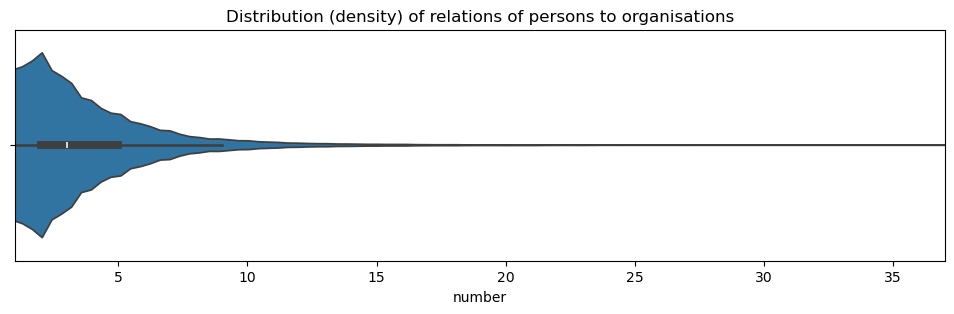

In [33]:
# Plot the distribution number of relations to organisations

min_val = df_pn.number.min()
max_val = df_pn.number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df_pn.number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

### Inspect the most connected persons

In [48]:
### Persons that have 10 or more relations to organisations
print(len(df_pn[df_pn.number > 9]))

703


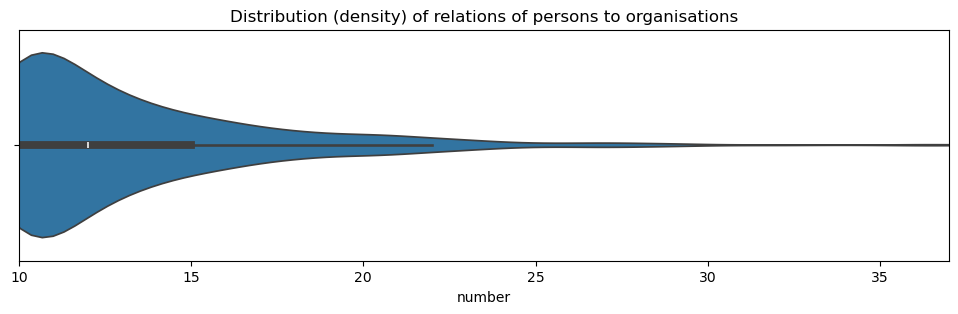

In [49]:
# Plot the distribution number of relations to organisations

df=df_pn[df_pn.number > 9]

min_val = df.number.min()
max_val = df.number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

In [50]:
### Number of types of relationships, all the persons
df_rela_type=pd.DataFrame(df_rel.groupby(by='relationship').size())
df_rela_type.columns=['number']

### Type of relationship of the 700 more connected persons (merge on the fly)
df_pn[df_pn.number > 9].merge(df_rel, left_index=True, right_on='person_uri').groupby(by='relationship').size()

df_rela_type=df_rela_type.join((df_pn[df_pn.number > 9].\
                   merge(df_rel, left_index=True, right_on='person_uri').groupby(by='relationship').size()).rename('rel_700'))

### Add the proportion between all the relations and those of the most connected persons
df_rela_type['prop']=df_rela_type.apply(lambda x: x['rel_700']/x['number'], axis=1)
### We observe that memberships are overrepresented for this very well known persons
df_rela_type


,number,rel_700,prop
relationship,,,
education,20843,1908,0.091542
employment,22636,2840,0.125464
membership,14879,4601,0.309228


### Distribution of relationships with organisations in relation to activity periods

Observe if periods are specific to relations and which ones 

In [51]:
### Distribution of RELATIONS by periods of activity
activities_per = pd.DataFrame(df_rel.groupby(by='periodsActivity').size())
activities_per.columns=['number_rel']
print(activities_per)

                 number_rel
periodsActivity            
1826-1850              1479
1851-1875              1688
1876-1900              2851
1901-1925              4103
1926-1950              7179
1951-1975             14139
1976-2000             18200
2001-2025              8719


In [53]:
### Distribution of PERSONS by periods of activity
period_per = pd.DataFrame(df_p.groupby(by='periodsActivity').size())
period_per.columns=['number_per']
print(period_per)

                 number_per
periodsActivity            
1826-1850               395
1851-1875               559
1876-1900               913
1901-1925              1416
1926-1950              2215
1951-1975              4695
1976-2000              6675
2001-2025              3175


In [54]:
df_ap_per=activities_per.join(period_per)

### Number of activities divided by number of persons
df_ap_per['proportion']=df_ap_per.apply(lambda x: x.number_rel/x.number_per, axis=1).round(3)
df_ap_per

,number_rel,number_per,proportion
periodsActivity,,,
1826-1850,1479,395,3.744
1851-1875,1688,559,3.020
1876-1900,2851,913,3.123
1901-1925,4103,1416,2.898
1926-1950,7179,2215,3.241
1951-1975,14139,4695,3.012
1976-2000,18200,6675,2.727
2001-2025,8719,3175,2.746


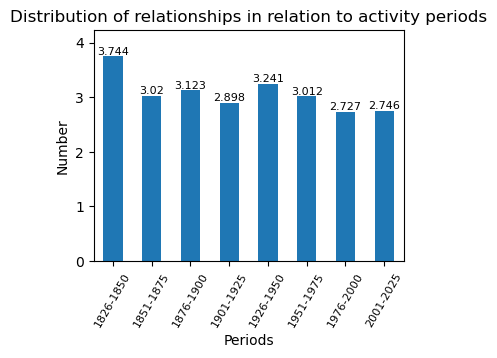

In [55]:
### Plot the evolution in time


ax = df_ap_per.proportion.plot(kind='bar',rot=50, fontsize=10, figsize=(4,3))
ax.bar_label(ax.containers[-1], size=8)


current_min, current_max = ax.get_ylim()
ax.set_ylim(current_min, current_max+0.3)

# Rotate labels 60 degrees and reduce font size
plt.xticks(rotation=60, fontsize=8)

plt.ylabel('Number')
plt.xlabel('Periods')
plt.title('Distribution of relationships in relation to activity periods')
plt.show()

In [68]:
### Create a cross-table
crosstab = pd.crosstab(df_rel['periodsActivity'],df_rel['relationship'])
# Optional: Remove the index name if you want a cleaner look
# crosstab.index.name = None
crosstab.columns.name = None
crosstab


,education,employment,membership
periodsActivity,,,
1826-1850,325,348,806
1851-1875,460,452,776
1876-1900,889,815,1147
1901-1925,1434,1430,1239
1926-1950,2489,2747,1943
1951-1975,5148,5497,3494
1976-2000,6728,7384,4088
2001-2025,3370,3963,1386


In [70]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: True


In [71]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 1957.01 , dof : 14
p-value : 0.0
Inertia (Phi-square):  0.034
Cramer:  0.129


#### Comment

A relation appears between type of relation and period. It is not strong but present, as we can observe in the heatmap of adjusted residuals: membership tends to be proportionally more present in the 19th century, while study and employment are more present in the 20th century. 

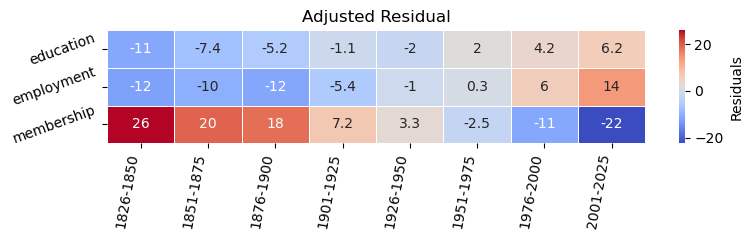

In [74]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 2.5))

## Relationships with organisations in relation to periods

### Universities - education

In [79]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='education']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['periodsActivity'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

In [91]:
### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct


Number of persons per organisation and period: 3039


periodsActivity,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025,sum
Harvard University,2,7,12,20,34,106,135,45,361
MSU Faculty of Physics,0,0,0,0,4,136,137,31,308
Massachusetts Institute of Technology,0,0,3,11,28,90,110,60,302
Lomonosov Moscow State University,0,0,3,10,44,93,109,21,280
University of Cambridge,1,1,9,18,48,72,77,47,273
"University of California, Berkeley",0,0,0,5,28,110,88,42,273
University of Göttingen,9,12,25,41,86,64,22,13,272
University of Vienna,13,14,22,40,59,36,35,20,239
Humboldt-Universität zu Berlin,7,19,28,70,64,29,13,7,237
Princeton University,0,0,0,5,23,63,83,54,228


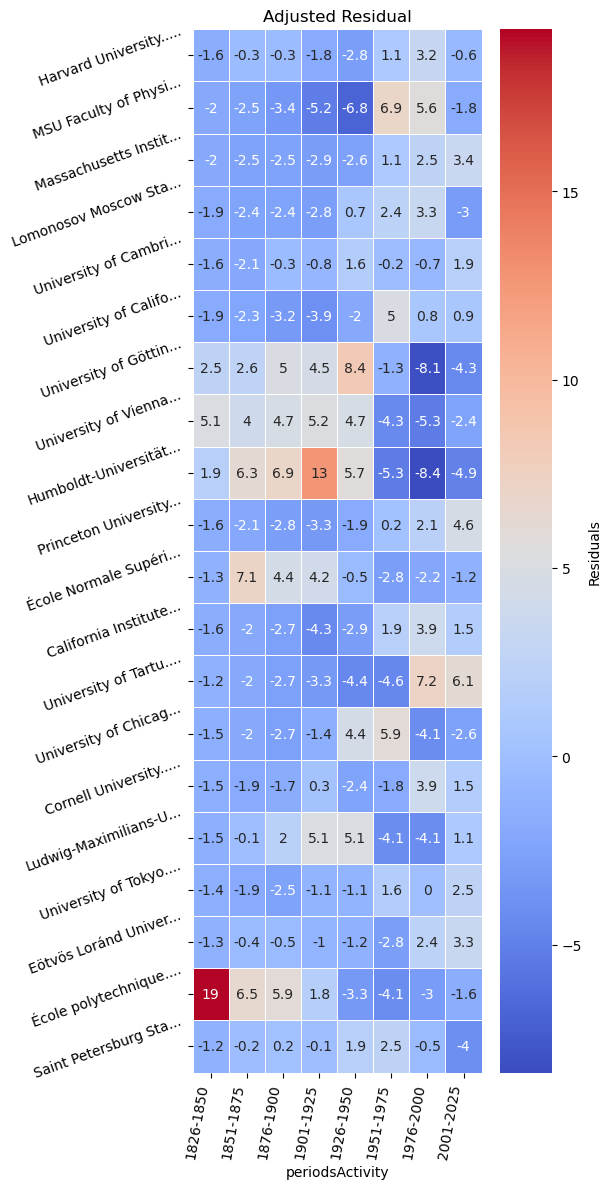

In [105]:
cct.index=[e[:20]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,12))

### Employers

In [112]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='employment']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['periodsActivity'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct

Number of persons per organisation and period: 4088


periodsActivity,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025,sum
Lomonosov Moscow State University,3,3,4,18,47,96,58,8,237
Harvard University,1,5,7,14,33,64,74,38,236
Massachusetts Institute of Technology,1,0,4,6,29,78,78,30,226
"University of California, Berkeley",0,2,0,7,23,64,72,28,196
Princeton University,1,1,2,8,19,40,63,31,165
California Institute of Technology,0,0,0,2,20,49,55,35,161
Technische Universität Berlin,0,3,2,14,30,28,28,44,149
University of Chicago,0,0,3,16,27,53,31,18,148
University of Tokyo,0,0,4,7,12,52,45,25,145
Humboldt-Universität zu Berlin,5,5,17,24,35,17,21,16,140


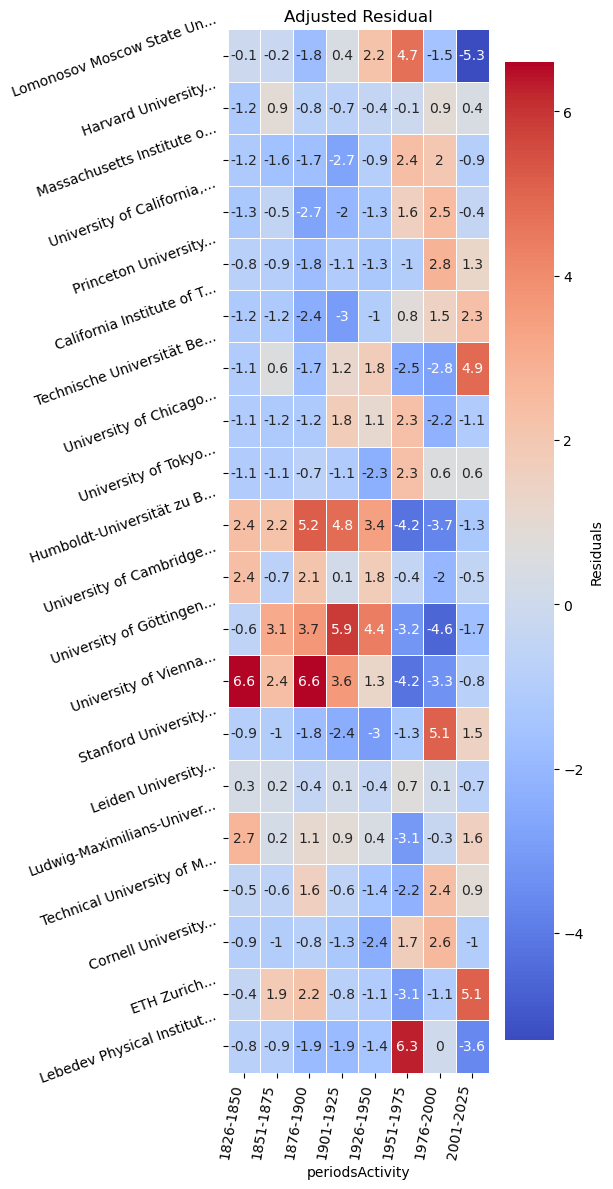

In [113]:
cct.index=[e[:25]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,12))

### Memberships

In [114]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='membership']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['periodsActivity'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct

Number of persons per organisation and period: 1293


periodsActivity,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025,sum
American Academy of Arts and Sciences,42,48,57,75,134,345,308,81,1090
National Academy of Sciences,12,35,59,73,138,342,319,84,1062
International Astronomical Union,0,0,4,8,24,67,422,342,867
Royal Society,76,65,86,74,107,197,153,30,788
German Academy of Sciences Leopoldina,35,41,108,76,91,116,86,55,608
Russian Academy of Sciences,30,28,38,52,89,180,162,12,591
French Academy of Sciences,44,37,42,44,46,70,84,14,381
Academia Europaea,0,0,0,0,0,74,236,68,378
Accademia Nazionale dei Lincei,17,43,69,59,49,65,50,15,367
American Philosophical Society,10,15,34,58,80,115,34,1,347


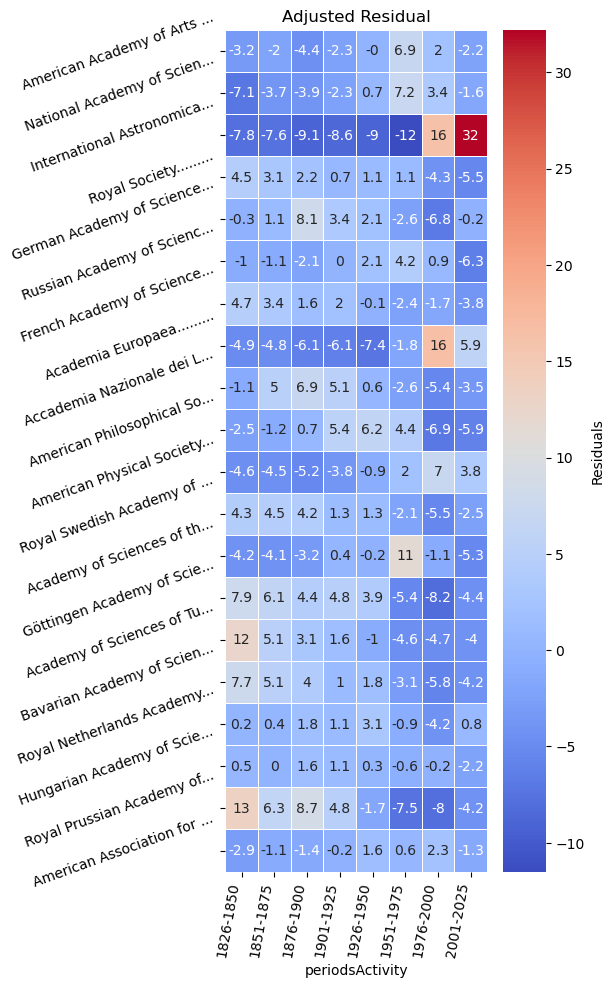

In [117]:
cct.index=[e[:25]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,10))

## Add years to approximate possible relations


In this exercice we artificially build relationships between persons without providing a measure of their real match to reality. In a heuristic perspective, the aim is just to have a consistent network in view of applying some analysis techniques.


We model artificial or imputed encounters based on the idea that persons present in the same institutions in the same period virtually know each other. But this is not alway the case although it allows to build person networks around organisations.

In [118]:
### fonction that codes the year of begin of an 'encounter'
def code_year_begin(type_relation, year):
    if type_relation=='education':
        begin=int(year)+20
    elif type_relation=='employment':
        begin=int(year)+28
    elif type_relation=='membership':
        begin=int(year)+40
    else :
        begin = 0

    return begin    

In [119]:
### function that codes the year of end of the virtual "encounter"
def code_year_end(type_relation, year):
    if type_relation=='education':
        end=int(year)+28
    elif type_relation=='employment':
        end=int(year)+65
    elif type_relation=='membership':
        end=int(year)+65
    else :
        end = 0
        
    return end

In [122]:
### Apply the functions 
df_rel['year_begin'] = df_rel.apply(lambda x : code_year_begin(x['relationship'], x['birthYear']), axis=1)
df_rel['year_end'] = df_rel.apply(lambda x : code_year_end(x['relationship'], x['birthYear']), axis=1)

In [123]:
df_rel[df_rel.relationship=='membership'].iloc[10:15]

,person_uri,labelPer,gender,birthYear,coded_country,periodsActivity,organisation_uri,organisation_label,relationship,year_begin,year_end
25,http://www.wikidata.org/entity/Q1640668,Jacques Etienne Bérard,male,1789,France,1826-1850,http://www.wikidata.org/entity/Q188771,French Academy of Sciences,membership,1829,1854
26,http://www.wikidata.org/entity/Q1640668,Jacques Etienne Bérard,male,1789,France,1826-1850,http://www.wikidata.org/entity/Q337555,Académie Nationale de Médecine,membership,1829,1854
27,http://www.wikidata.org/entity/Q5439505,Fearon Fallows,male,1788,United Kingdom,1826-1850,http://www.wikidata.org/entity/Q123885,Royal Society,membership,1828,1853
32,http://www.wikidata.org/entity/Q5439505,Fearon Fallows,male,1788,United Kingdom,1826-1850,http://www.wikidata.org/entity/Q753299,Royal Astronomical Society,membership,1828,1853
34,http://www.wikidata.org/entity/Q3750372,Francesco Orioli,male,1783,Italy,1826-1850,http://www.wikidata.org/entity/Q2822396,Academy of Sciences of Turin,membership,1823,1848


## Create pairs of persons: education

Create relations of persons through relations to organisations

In [256]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='education'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'periodsActivity']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

20843


In [257]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_edu = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_edu))

1807685


In [258]:
### Inspect
merged_edu.head(2)

,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,periodsActivity_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,periodsActivity_y
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q153978,University of Tübingen,1949,1957,1951-1975,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1949,1957,1951-1975
1,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q153978,University of Tübingen,1949,1957,1951-1975,http://www.wikidata.org/entity/Q100212,Peter Kramer,1953,1961,1976-2000


In [259]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_edu = merged_edu[merged_edu['person_uri_x'] < (merged_edu['person_uri_y'])]
print(len(merged_edu), '-', len(merged_edu)*2)

893421 - 1786842


In [260]:
### Restrict time overlap (allow only 7 years overlap) — could be extended to have a larger result

# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_edu = merged_edu[(merged_edu['year_begin_y'] < merged_edu['year_end_x']) & (merged_edu['year_begin_x'] < merged_edu['year_end_y'])]
print(len(merged_edu))

## We observe that linked people are not necessarily in the same activity period
merged_edu.head(3)


153438


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,periodsActivity_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,periodsActivity_y
1,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q153978,University of Tübingen,1949,1957,1951-1975,http://www.wikidata.org/entity/Q100212,Peter Kramer,1953,1961,1976-2000
3,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q153978,University of Tübingen,1949,1957,1951-1975,http://www.wikidata.org/entity/Q102931598,Alfred Reule,1944,1952,1951-1975
10,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q153978,University of Tübingen,1949,1957,1951-1975,http://www.wikidata.org/entity/Q118363,Wolfgang Demtröder,1951,1959,1976-2000


In [261]:
gbe_edu = duckdb.query("""
    
    SELECT organisation_label, COUNT(*) as number
    FROM merged_edu
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_edu.iloc[:10]

,organisation_label,number
0,MSU Faculty of Physics,12754
1,Harvard University,10253
2,Lomonosov Moscow State University,7764
3,Massachusetts Institute of Technology,7745
4,"University of California, Berkeley",6699
5,University of Cambridge,4834
6,University of Tartu,4777
7,University of Göttingen,4483
8,California Institute of Technology,4352
9,Princeton University,4275


### Create network of persons relationships during studies

#### Example of connected persons

Displayed with **Allegrograph Gruff**

<img src="images/alg_gruff_example_chinese_connected_education.png" alt="drawing" width="700"/>

In [262]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_edu = merged_edu.groupby(by=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'periodsActivity_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_edu['number'] = gr_edu.organisation_label.apply(lambda x : len(x.split('|')))

print(len(gr_edu))


151525


In [263]:
gr_edu=gr_edu.reset_index()
gr_edu.sort_values(by='number', ascending=False).head()

,person_uri_x,person_uri_y,periodsActivity_x,year_begin_x,year_end_x,year_begin_y,year_end_y,periodsActivity_y,organisation_label,organisation_uri,number
80731,http://www.wikidata.org/entity/Q181369,http://www.wikidata.org/entity/Q183679,1951-1975,1942,1950,1946,1954,1951-1975,University of Chicago|Tsinghua University|Nank...,http://www.wikidata.org/entity/Q131252|http://...,5
148778,http://www.wikidata.org/entity/Q742536,http://www.wikidata.org/entity/Q9095,1876-1900,1851,1859,1851,1859,1876-1900,Peterhouse|University of Cambridge|Edinburgh A...,http://www.wikidata.org/entity/Q650068|http://...,4
10182,http://www.wikidata.org/entity/Q105711,http://www.wikidata.org/entity/Q7057796,1951-1975,1937,1945,1930,1938,1951-1975,Deutsche wissenschaftliche Prüfungs-kommission...,http://www.wikidata.org/entity/Q102398119|http...,3
10179,http://www.wikidata.org/entity/Q105711,http://www.wikidata.org/entity/Q4256995,1951-1975,1937,1945,1938,1946,1951-1975,Deutsche wissenschaftliche Prüfungs-kommission...,http://www.wikidata.org/entity/Q102398119|http...,3
15619,http://www.wikidata.org/entity/Q109662645,http://www.wikidata.org/entity/Q29034278,1951-1975,1933,1941,1937,1945,1951-1975,Massachusetts Institute of Technology|Fisk Uni...,http://www.wikidata.org/entity/Q49108|http://w...,3


In [264]:
### change columns names
gr_edu.columns=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'periodsActivity_y', 'orgs_labels', 'orgs_uris', 'orgs_number']
### change columns positions
gr_edu = gr_edu[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'periodsActivity_x',  'periodsActivity_y']]
gr_edu.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,periodsActivity_x,periodsActivity_y
80731,http://www.wikidata.org/entity/Q181369,http://www.wikidata.org/entity/Q183679,University of Chicago|Tsinghua University|Nank...,5,http://www.wikidata.org/entity/Q131252|http://...,1951-1975,1951-1975
148778,http://www.wikidata.org/entity/Q742536,http://www.wikidata.org/entity/Q9095,Peterhouse|University of Cambridge|Edinburgh A...,4,http://www.wikidata.org/entity/Q650068|http://...,1876-1900,1876-1900


In [265]:
print('More then 2 relations:', len(gr_edu[gr_edu.orgs_number>2]), '\n2 relations:', len(gr_edu[gr_edu.orgs_number==2]),
      '\none relation:', len(gr_edu[gr_edu.orgs_number==1]))

More then 2 relations: 25 
2 relations: 1860 
one relation: 149640


In [188]:

### Do not use

### Find persons in different periods

## We observe that there is significant overlap: more than 30000
# Periods are as a matter of fact an artificial construct !

#print(len(gr_mer[gr_mer.periodsActivity_x != gr_mer.periodsActivity_y]))
#gr_mer[gr_mer.periodsActivity_x != gr_mer.periodsActivity_y].sort_values(by='orgs_number', ascending=False).iloc[:5]

## Create pairs of persons: employment


Create relations of persons through relations to organisations

In [266]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='employment'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'periodsActivity']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

22636


In [267]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_empl = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_empl))


1069110


In [268]:
merged_empl.head(2)

,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,periodsActivity_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,periodsActivity_y
0,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,http://www.wikidata.org/entity/Q161562,California Institute of Technology,1920,1957,1926-1950,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1920,1957,1926-1950
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,http://www.wikidata.org/entity/Q161562,California Institute of Technology,1920,1957,1926-1950,http://www.wikidata.org/entity/Q102273290,Charles William Peck,1962,1999,1976-2000


In [269]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_empl = merged_empl[merged_empl['person_uri_x'] < (merged_empl['person_uri_y'])]
print(len(merged_empl), '-', len(merged_empl)*2)

523237 - 1046474


In [270]:
### Restrict time overlap : from 28 to 65
# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_empl = merged_empl[(merged_empl['year_begin_y'] < merged_empl['year_end_x']) & (merged_empl['year_begin_x'] < merged_empl['year_end_y'])]
print(len(merged_empl))

## We observe that linked people are not necessarily in the same activity period
merged_empl.head(3)


331374


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,periodsActivity_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,periodsActivity_y
2,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,http://www.wikidata.org/entity/Q161562,California Institute of Technology,1920,1957,1926-1950,http://www.wikidata.org/entity/Q102306320,William Edward Deeds,1948,1985,1951-1975
6,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,http://www.wikidata.org/entity/Q161562,California Institute of Technology,1920,1957,1926-1950,http://www.wikidata.org/entity/Q109587870,J. Harold Wayland,1937,1974,1951-1975
8,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,http://www.wikidata.org/entity/Q161562,California Institute of Technology,1920,1957,1926-1950,http://www.wikidata.org/entity/Q111028460,John B. Irwin,1937,1974,1951-1975


In [271]:
gbe_empl = duckdb.query("""
    SELECT organisation_label, COUNT(*) as number
    FROM merged_empl
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_empl.iloc[:5]

,organisation_label,number
0,Lomonosov Moscow State University,18793
1,Massachusetts Institute of Technology,17522
2,Harvard University,15594
3,"University of California, Berkeley",13393
4,California Institute of Technology,9055


### Create network of persons relationships during emloyment

In [272]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_empl = merged_empl.groupby(by=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'periodsActivity_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_empl['number'] = gr_empl.organisation_label.apply(lambda x : len(x.split('|')))

print(len(gr_empl))


323847


In [273]:
gr_empl=gr_empl.reset_index()
gr_empl.sort_values(by='number', ascending=False).head(2)

,person_uri_x,person_uri_y,periodsActivity_x,year_begin_x,year_end_x,year_begin_y,year_end_y,periodsActivity_y,organisation_label,organisation_uri,number
221591,http://www.wikidata.org/entity/Q246497,http://www.wikidata.org/entity/Q707137,1951-1975,1939,1976,1928,1965,1926-1950,Academy of Sciences of the USSR|Central Aerohy...,http://www.wikidata.org/entity/Q2370801|http:/...,5
187339,http://www.wikidata.org/entity/Q19544957,http://www.wikidata.org/entity/Q363435,1976-2000,1968,2005,1995,2032,2001-2025,Harvard–Smithsonian Center for Astrophysics|Ha...,http://www.wikidata.org/entity/Q1133697|http:/...,4


In [274]:
### change columns names
gr_empl.columns=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'periodsActivity_y', 'orgs_labels', 'orgs_uris', 'orgs_number']
### change columns positions
gr_empl = gr_empl[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'periodsActivity_x', 'periodsActivity_y']]
gr_empl.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,periodsActivity_x,periodsActivity_y
221591,http://www.wikidata.org/entity/Q246497,http://www.wikidata.org/entity/Q707137,Academy of Sciences of the USSR|Central Aerohy...,5,http://www.wikidata.org/entity/Q2370801|http:/...,1951-1975,1926-1950
187339,http://www.wikidata.org/entity/Q19544957,http://www.wikidata.org/entity/Q363435,Harvard–Smithsonian Center for Astrophysics|Ha...,4,http://www.wikidata.org/entity/Q1133697|http:/...,1976-2000,2001-2025


In [275]:
print('More then 2 relations:', len(gr_empl[gr_empl.orgs_number>2]), 
      '\n2 relations:', len(gr_empl[gr_empl.orgs_number==2]),
      '\n1 relations:', len(gr_empl[gr_empl.orgs_number==1]))

More then 2 relations: 299 
2 relations: 6890 
1 relations: 316658


In [276]:
print(gr_empl.orgs_number.max())

5


## Create pairs of persons: membership

Create relations of persons through relations to organisations

In [277]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='membership'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'periodsActivity']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

14879


In [278]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_memb = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_memb))


5835807


In [279]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_memb = merged_memb[merged_memb['person_uri_x'] < (merged_memb['person_uri_y'])]
print(len(merged_memb), '-', len(merged_memb)*2)

2910464 - 5820928


In [280]:
### Restrict time overlap (allow only 7 years overlap) — could be extended to have a larger result

# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_memb = merged_memb[(merged_memb['year_begin_y'] < merged_memb['year_end_x']) & (merged_memb['year_begin_x'] < merged_memb['year_end_y'])]
print(len(merged_memb))

## We observe that linked people are not necessarily in the same activity period
merged_memb.head(3)


1240253


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,periodsActivity_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,periodsActivity_y
1,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q543804,German Academy of Sciences Leopoldina,1969,1994,1951-1975,http://www.wikidata.org/entity/Q100216,Willi Kalender,1989,2014,1976-2000
7,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q543804,German Academy of Sciences Leopoldina,1969,1994,1951-1975,http://www.wikidata.org/entity/Q102226864,Werner Känzig,1962,1987,1951-1975
10,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,http://www.wikidata.org/entity/Q543804,German Academy of Sciences Leopoldina,1969,1994,1951-1975,http://www.wikidata.org/entity/Q103854,Aage Bohr,1962,1987,1951-1975


In [281]:
### count relations by organisation
gbe_memb=duckdb.query("""
    SELECT organisation_label, COUNT(*) as number
    FROM merged_memb
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_memb.iloc[:5]

,organisation_label,number
0,International Astronomical Union,260033
1,National Academy of Sciences,237685
2,American Academy of Arts and Sciences,233831
3,Royal Society,88610
4,Russian Academy of Sciences,68782


### Create network of persons relationships during membership

In [578]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_memb = merged_memb.groupby(by=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'periodsActivity_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_memb['number'] = gr_memb.organisation_label.apply(lambda x : len(x.split('|')))

print(len(gr_memb))


997706


In [579]:
gr_memb=gr_memb.reset_index()
gr_memb.sort_values(by='number', ascending=False).head()

,person_uri_x,person_uri_y,periodsActivity_x,year_begin_x,year_end_x,year_begin_y,year_end_y,periodsActivity_y,organisation_label,organisation_uri,number
830718,http://www.wikidata.org/entity/Q41688,http://www.wikidata.org/entity/Q81082,1876-1900,1893,1918,1894,1919,1876-1900,Royal Swedish Academy of Sciences|Academy of S...,http://www.wikidata.org/entity/Q191583|http://...,16
990806,http://www.wikidata.org/entity/Q81082,http://www.wikidata.org/entity/Q83297,1876-1900,1894,1919,1882,1907,1876-1900,Academy of Sciences of Turin|Royal Prussian Ac...,http://www.wikidata.org/entity/Q2822396|http:/...,15
944039,http://www.wikidata.org/entity/Q60024,http://www.wikidata.org/entity/Q83297,1851-1875,1861,1886,1882,1907,1876-1900,Royal Netherlands Academy of Arts and Sciences...,http://www.wikidata.org/entity/Q253439|http://...,14
974980,http://www.wikidata.org/entity/Q71031,http://www.wikidata.org/entity/Q8750,1851-1875,1851,1876,1831,1856,1826-1850,Royal Society|National Academy of Sciences|Fre...,http://www.wikidata.org/entity/Q123885|http://...,14
973131,http://www.wikidata.org/entity/Q7085,http://www.wikidata.org/entity/Q937,1926-1950,1925,1950,1919,1944,1901-1925,Japan Academy|Royal Society|Royal Swedish Acad...,http://www.wikidata.org/entity/Q1683229|http:/...,14


In [580]:
### change columns names
gr_memb.columns=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'periodsActivity_y', 'orgs_labels', 'orgs_uris', 'orgs_number']

In [581]:
### change columns positions
gr_memb = gr_memb[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'periodsActivity_x', 'periodsActivity_y']]
gr_memb.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,periodsActivity_x,periodsActivity_y
830718,http://www.wikidata.org/entity/Q41688,http://www.wikidata.org/entity/Q81082,Royal Swedish Academy of Sciences|Academy of S...,16,http://www.wikidata.org/entity/Q191583|http://...,1876-1900,1876-1900
990806,http://www.wikidata.org/entity/Q81082,http://www.wikidata.org/entity/Q83297,Academy of Sciences of Turin|Royal Prussian Ac...,15,http://www.wikidata.org/entity/Q2822396|http:/...,1876-1900,1876-1900


In [582]:
print('More then 2 relations:', len(gr_memb[gr_memb.orgs_number>2]), 
      '\n2 relations:', len(gr_memb[gr_memb.orgs_number==2]),
      '\none relation:', len(gr_memb[gr_memb.orgs_number==1]))

More then 2 relations: 39041 
2 relations: 143107 
one relation: 815558


In [583]:
print('More then 4 relations:', len(gr_memb[gr_memb.orgs_number>4]), 
      '\n4 relations:', len(gr_memb[gr_memb.orgs_number==4]),
      '\n3 relations:', len(gr_memb[gr_memb.orgs_number==3]))

More then 4 relations: 4676 
4 relations: 6591 
3 relations: 27774


In [584]:
print('More then 10 relations:', len(gr_memb[gr_memb.orgs_number>10]), '\n10 relations:', len(gr_memb[gr_memb.orgs_number==10]))

More then 10 relations: 148 
10 relations: 112


In [585]:
print(gr_memb.orgs_number.max())

16


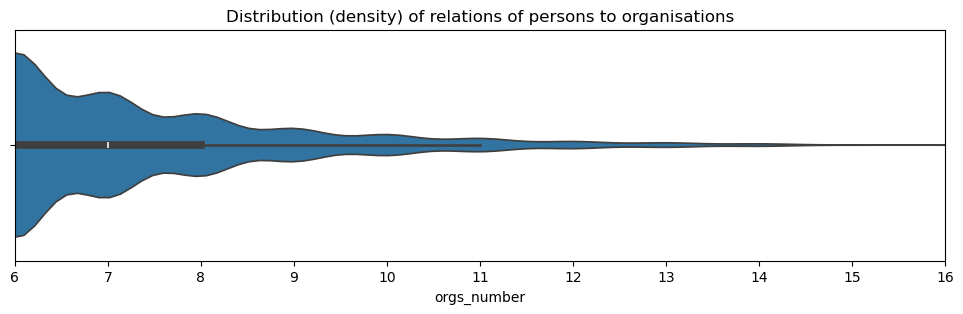

In [586]:
# Plot the distribution of eigenvector density

df=gr_memb[gr_memb.orgs_number>5]

min_val = df.orgs_number.min()
max_val = df.orgs_number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.orgs_number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

## Most frequent organisations as relations

Organisations where memberships' relationship happen are different from those where people are educated and are employed, as we can see if we compare the tables below.

We therefore just join educational institutions and employers

In [296]:
gbe_edu.head()

,organisation_label,number
0,MSU Faculty of Physics,12754
1,Harvard University,10253
2,Lomonosov Moscow State University,7764
3,Massachusetts Institute of Technology,7745
4,"University of California, Berkeley",6699


In [ ]:
gbe_empl.head()

,organisation_label,number
0,Lomonosov Moscow State University,18793
1,Massachusetts Institute of Technology,17522
2,Harvard University,15594
3,"University of California, Berkeley",13393
4,California Institute of Technology,9055


In [297]:
gbe_memb.head()

,organisation_label,number
0,International Astronomical Union,260033
1,National Academy of Sciences,237685
2,American Academy of Arts and Sciences,233831
3,Royal Society,88610
4,Russian Academy of Sciences,68782


In [298]:
### Join first hundred organisation for education and employment

gb_organ_of_rel=pd.merge(left=gbe_edu, on='organisation_label', right=gbe_empl,
                suffixes=('_rel_edu', '_rel_empl'), how='outer')
gb_organ_of_rel[['number_rel_edu','number_rel_empl']]=gb_organ_of_rel[['number_rel_edu','number_rel_empl']].fillna(0).astype('int')
print(len(gb_organ_of_rel))
gb_organ_of_rel.head()

141


,organisation_label,number_rel_edu,number_rel_empl
0,Adam Mickiewicz University in Poznań,460,1135
1,All-Russian Scientific Research Institute of E...,0,728
2,B Verkin Institute for Low Temperature Physics...,0,619
3,B.I. Stepanov Institute of Physics,0,1072
4,Baku State University,192,0


In [299]:
gb_organ_of_rel.sort_values(by='number_rel_edu', ascending=False).iloc[:20]
#gb_organ_of_rel.sort_values(by='number_rel_empl', ascending=False).iloc[:30]


,organisation_label,number_rel_edu,number_rel_empl
52,MSU Faculty of Physics,12754,1316
30,Harvard University,10253,15594
48,Lomonosov Moscow State University,7764,18793
53,Massachusetts Institute of Technology,7745,17522
98,"University of California, Berkeley",6699,13393
102,University of Cambridge,4834,4502
124,University of Tartu,4777,1065
107,University of Göttingen,4483,3922
9,California Institute of Technology,4352,9055
71,Princeton University,4275,8806


## Merge the three networks: where do the encounters happen?

We merge the three tables of relations (education, employment, membership) and observe where encounters happen.

In [378]:
network=pd.merge(gr_edu, gr_empl, on=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'periodsActivity_y'],
                 how='outer', suffixes=('_edu', '_empl'), indicator=True)

In [379]:
network.rename(columns={'_merge': 'merge_1'}, inplace=True)

In [380]:
network.sort_values(by='orgs_number_edu', ascending=False).head(3)

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,orgs_uris_edu,periodsActivity_x,periodsActivity_y,orgs_labels_empl,orgs_number_empl,orgs_uris_empl,merge_1
246685,http://www.wikidata.org/entity/Q181369,http://www.wikidata.org/entity/Q183679,University of Chicago|Tsinghua University|Nank...,5.0,http://www.wikidata.org/entity/Q131252|http://...,1951-1975,1951-1975,NaN,NaN,NaN,left_only
454178,http://www.wikidata.org/entity/Q742536,http://www.wikidata.org/entity/Q9095,Peterhouse|University of Cambridge|Edinburgh A...,4.0,http://www.wikidata.org/entity/Q650068|http://...,1876-1900,1876-1900,NaN,NaN,NaN,left_only
24291,http://www.wikidata.org/entity/Q105711,http://www.wikidata.org/entity/Q7057796,Deutsche wissenschaftliche Prüfungs-kommission...,3.0,http://www.wikidata.org/entity/Q102398119|http...,1951-1975,1951-1975,NaN,NaN,NaN,left_only


In [381]:
network=pd.merge(network, gr_memb, on=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'periodsActivity_y' ],
                 how='outer', suffixes=('', '_memb'), indicator=True)

In [382]:
network.rename(columns={'organisation_label': 'orgs_labels_memb','number': 'orgs_number_memb','organisation_uri': 'orgs_uris_memb'}, inplace=True)

In [383]:
network['orgs_number_edu'].fillna(0, inplace=True)
network['orgs_number_empl'].fillna(0, inplace=True)
network['orgs_number_memb'].fillna(0, inplace=True)
network['orgs_number_memb']=network['orgs_number_memb'].astype(int)
network['orgs_number_edu']=network['orgs_number_edu'].astype(int)
network['orgs_number_empl']=network['orgs_number_empl'].astype(int)


In [384]:
network=network[['person_uri_x', 'person_uri_y', 'orgs_labels_edu', 'orgs_number_edu', 'periodsActivity_x', 'periodsActivity_y', 'orgs_labels_empl', 'orgs_number_empl', 'orgs_labels_memb', 'orgs_number_memb']]

In [385]:
network.iloc[550:555]

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,periodsActivity_x,periodsActivity_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb
550,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q638644,NaN,0,1926-1950,1951-1975,California Institute of Technology,1,NaN,0
551,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q64550,NaN,0,1926-1950,1926-1950,NaN,0,National Academy of Sciences,1
552,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q649387,NaN,0,1926-1950,1951-1975,California Institute of Technology,1,National Academy of Sciences|American Philosop...,2
553,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q651059,NaN,0,1926-1950,1926-1950,NaN,0,National Academy of Sciences,1
554,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q6520764,NaN,0,1926-1950,1926-1950,NaN,0,National Academy of Sciences|American Philosop...,2


In [386]:
### create field with addition edu and empl
network['sum_edu_empl']=network['orgs_number_edu']+network['orgs_number_empl']

In [387]:
### create field with sum of all values
network['sum_all_rel']=network['orgs_number_edu']+network['orgs_number_empl']+network['orgs_number_memb']

#### Add persons' labels

In [388]:
network=pd.merge(left=network,right=df_p[['person_uri','labelPer']], left_on='person_uri_x', right_on='person_uri')

In [ ]:
network.drop(columns=['person_uri'], inplace=True)

In [392]:
network=pd.merge(left=network,right=df_p[['person_uri','labelPer']], left_on='person_uri_y', right_on='person_uri', suffixes=('_x1', '_y'))


In [394]:
network.rename(columns={'labelPer_x1': 'labelPer_x'}, inplace=True)

In [395]:
network.drop(columns=['person_uri'], inplace=True)

In [396]:
network.head(2)

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,periodsActivity_x,periodsActivity_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb,sum_edu_empl,sum_all_rel,labelPer_x,labelPer_y
0,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q100212,University of Tübingen,1,1951-1975,1976-2000,NaN,0,NaN,0,1,1,Hans Elsässer,Peter Kramer
1,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q100216,NaN,0,1951-1975,1976-2000,NaN,0,German Academy of Sciences Leopoldina,1,0,1,Hans Elsässer,Willi Kalender


In [397]:
### Change columns order
network=network[['labelPer_x',
  'labelPer_y',
'periodsActivity_x', 'periodsActivity_y',
 'sum_edu_empl', ### study and employment relationshipa
 'sum_all_rel', ### all the relationships
 'orgs_number_edu',  'orgs_labels_edu', 
 'orgs_number_empl', 'orgs_labels_empl',
 'orgs_number_memb', 'orgs_labels_memb',
 'person_uri_x', 'person_uri_y'
   ]]

In [414]:
### SQL Queries


# order by max sum of edu and empl relations
query_1="""
    SELECT *
    FROM network
    ORDER BY sum_edu_empl DESC
    LIMIT 5
"""


# order by max sum of all relations
query_2="""
    SELECT *
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
    ORDER BY sum_all_rel DESC
    --OFFSET 500
    LIMIT 10
"""



# order by max  edu and empl relations
query_3="""
    SELECT *
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
    ORDER BY orgs_number_empl DESC, orgs_number_edu DESC
    --OFFSET 500
    LIMIT 10
"""

In [415]:
duckdb.query(query_3).to_df()

,labelPer_x,labelPer_y,periodsActivity_x,periodsActivity_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
0,Hitoshi Murayama,Hirosi Ooguri,2001-2025,2001-2025,5,6,1,University of Tokyo,4,Institute for the Physics and Mathematics of t...,1,American Academy of Arts and Sciences,http://www.wikidata.org/entity/Q11523125,http://www.wikidata.org/entity/Q1620293
1,David Latham,Giovanni G. Fazio,1976-2000,1976-2000,5,6,1,Massachusetts Institute of Technology,4,Harvard–Smithsonian Center for Astrophysics|Ha...,1,International Astronomical Union,http://www.wikidata.org/entity/Q19544957,http://www.wikidata.org/entity/Q58455161
2,Leonid Sedov,Mstislav Keldysh,1951-1975,1951-1975,5,8,1,Lomonosov Moscow State University,4,Keldysh Research Center|Central Aerohydrodynam...,3,German Academy of Sciences Leopoldina|American...,http://www.wikidata.org/entity/Q1973460,http://www.wikidata.org/entity/Q246497
3,Leonid Sedov,Mikhail Lavrentyev,1951-1975,1926-1950,5,8,1,Lomonosov Moscow State University,4,Steklov Institute of Mathematics|Central Aeroh...,3,German Academy of Sciences Leopoldina|Russian ...,http://www.wikidata.org/entity/Q1973460,http://www.wikidata.org/entity/Q707137
4,Christine Jones Forman,Lars Hernquist,1976-2000,1976-2000,5,5,1,Harvard University,4,Harvard–Smithsonian Center for Astrophysics|Ha...,0,None,http://www.wikidata.org/entity/Q2669110,http://www.wikidata.org/entity/Q3218144
5,Gaspard-Gustave de Coriolis,Jean-Baptiste-Charles-Joseph Bélanger,1826-1850,1826-1850,5,6,2,École Nationale des Ponts et Chaussées|École p...,3,École polytechnique|École Nationale des Ponts ...,1,Academy of Sciences of Turin,http://www.wikidata.org/entity/Q202827,http://www.wikidata.org/entity/Q635389
6,Dennis W. Sciama,Thomas Gold,1951-1975,1951-1975,5,8,2,University of Cambridge|Trinity College,3,Cornell University|University of Cambridge|Har...,3,American Philosophical Society|American Academ...,http://www.wikidata.org/entity/Q284336,http://www.wikidata.org/entity/Q93562
7,Vadim Lashkaryov,Васіль Ляшэнка,1926-1950,1926-1950,4,4,1,Taras Shevchenko National University of Kyiv,3,Institute of Physics NAS of Ukraine|Institute ...,0,None,http://www.wikidata.org/entity/Q12117228,http://www.wikidata.org/entity/Q12119488
8,Dmitry Blokhintsev,Fyodor Shapiro,1951-1975,1951-1975,4,5,1,MSU Faculty of Physics,3,Joint Institute for Nuclear Research|Lomonosov...,1,Academy of Sciences of the USSR,http://www.wikidata.org/entity/Q1232515,http://www.wikidata.org/entity/Q4520215
9,Walter Grotrian,Hans Kopfermann,1926-1950,1926-1950,4,4,1,University of Göttingen,3,Humboldt-Universität zu Berlin|Technische Univ...,0,None,http://www.wikidata.org/entity/Q89492,http://www.wikidata.org/entity/Q97326


In [416]:
print('Tot:', len(network), 'Edu:', len
      (gr_edu), ', Empl:', len(gr_empl), ', Memb:', len(gr_memb))

Tot: 1405286 Edu: 151525 , Empl: 323847 , Memb: 997706


count    15962.000000
mean         4.784300
std          1.416346
min          4.000000
25%          4.000000
50%          4.000000
75%          5.000000
max         17.000000
Name: sum_all_rel, dtype: float64


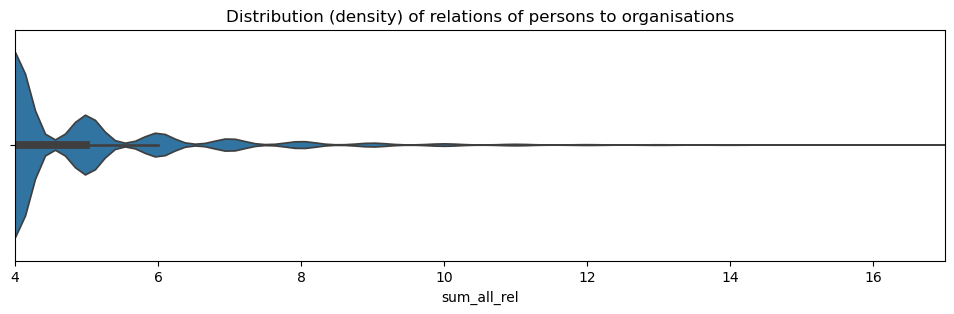

In [418]:
### We only consider in the distribution more than three
df=network[network.sum_all_rel>3]
print(df.sum_all_rel.describe())

### Plot the distribution of the total number of relations
# where there are more than 3 relations
min_val = df.sum_all_rel.min()
max_val = df.sum_all_rel.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.sum_all_rel, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

### Correlations

We could wonder if the fact of studying together, or working together would lead to be member of the same organisations.

Given the large amount of people having just one or to relation, we only consider people having at least four relationships.

We use here ranking correlation given that we are counting relations

Surprisingly:
* there is some weak positive relation between studying and working together
* but there is a stronger negative correlation between studying or working together and being member of same organisations 


In [419]:
df=network[network.sum_all_rel>3]
print(len(df))

15962


In [420]:
### We export the dataframe df for manual inspection
filename='data/df_network_correlations_20260511.csv'
df.sort_values(by=['orgs_number_edu','orgs_number_empl'],ascending=False).to_csv(filename, index=False)

In [422]:
### Alternatively you can create a table in the sqlite database
# in order to inspect it there

# N.B this is optional !


db = '../../data/data_analysis.db'

table_name='df_network_correlations'

conn = sql.connect(db)
# cursor = conn.cursor()
df.sort_values(by=['orgs_number_edu','orgs_number_empl'],ascending=False).to_sql(table_name, conn, if_exists='replace', index=True)
conn.close()

#### Relationships in studies and in employment

We only can use rank correlation given these are counts. 

Also, most educational relations have count: 1 - so the correlation does not really make sense

In [424]:
predictor_name='orgs_number_edu' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_empl'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis: on ranking because these are counts
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: 0.1855 (p-value: 0.0000)


#### Relationships in studies and in membership

In [425]:

predictor_name='orgs_number_edu' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_memb'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis: on ranking because these are counts
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.4218 (p-value: 0.0000)


#### Relationships in employment and in membership

In [426]:

predictor_name='orgs_number_empl' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_memb'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.5956 (p-value: 0.0000)


## Explore the education relationships graph


We will now transform our networks into graphs using the Python *networkx* library

### Education

In [427]:
print(len(gr_edu))

151525


In [428]:
## Provide the data in the format 
# required by Networkx

l = [tuple(
    (e['person_uri_x'], e['person_uri_y'],
     {'orgsUris':e['orgs_uris'], 'orgsLabels':e['orgs_labels'], 'orgsNumber':e['orgs_number'],   
      'periods_x':e['periodsActivity_x'], 'periods_y':e['periodsActivity_y']}
     )) 
     for e in gr_edu.to_dict(orient='records')]
print(len(l))

151525


In [429]:
## Créate the empty graph
G_edu=nx.Graph()

## Add relationships to graph
# Multiple rows between two edges are taken only once
G_edu.add_edges_from(l)

naf.basic_graph_properties(G_edu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 12576,
 'number_of_edges': 151525,
 '------': '------',
 'is connected': False,
 'components': 308,
 'density': 0.0019163011751374703}


#### Add metadata to nodes

In [430]:
df_p.head(2)

,person_uri,labelPer,gender,birthYear,coded_country,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,male,1786,France,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,male,1782,Germany,1826-1850


In [435]:
df_pm = df_p[['person_uri','labelPer', 'birthYear', 'periodsActivity','coded_country']]
df_pm = df_pm.drop_duplicates()
df_pm.columns=['uri', 'label', 'birthYear', 'periodsActivity','coded_country']
df_pm.head()


,uri,label,birthYear,periodsActivity,coded_country
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,1826-1850,France
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,1826-1850,Germany
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,1826-1850,Ukraine
3,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1781,1826-1850,Germany
4,http://www.wikidata.org/entity/Q22331669,Carlo Brioschi,1782,1826-1850,Italy


In [436]:
### Prepare data to add to nodes
# The data must be of type : dictionary, i.e. key:value structure
ln = dict([(e['uri'],
     {'label':e['label'], 
       'birthYear':e['birthYear'],
       'periodsActivity':e['periodsActivity'],
      'coded_country':e['coded_country']}
     ) for e in df_pm.to_dict(orient='records')])
# print(str(l)[:200])


In [437]:

## Add attributes
nx.set_node_attributes(G_edu, ln)
pprint.pprint(list(G_edu.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000193',
  {'birthYear': 1929,
   'coded_country': 'Germany',
   'label': 'Hans Elsässer',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q100212',
  {'birthYear': 1933,
   'coded_country': 'Germany',
   'label': 'Peter Kramer',
   'periodsActivity': '1976-2000'})]


In [438]:
naf.basic_graph_properties(G_edu)

{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 12576,
 'number_of_edges': 151525,
 '------': '------',
 'is connected': False,
 'components': 308,
 'density': 0.0019163011751374703}


#### Components

In [439]:
### Create a list of graphs, one per component
perS = [G_edu.subgraph(c).copy() for c in nx.connected_components(G_edu)]

### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
ln = sorted([[i,len(s.nodes)] for i,s in enumerate(perS)], key = lambda row: row[1], reverse=True)
print(ln[:5])

### Again we observe that there is a big connected graphe 
# and a multitude of small graphs

[[0, 11441], [15, 92], [33, 38], [30, 22], [76, 22]]


### Explore small graph

In [440]:
### 
li = [15]    # [15, 33, 30, 76]
ll = [list(perS[i[0]].nodes.data()) for i in ln if i[0] in li ]
#pprint.pprint(str(ll)[:300])

In [441]:

# Display variable

variable_name = 'edu_76'

globals()[variable_name] = nx.Graph()

gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    gu = nx.union(gu, perS[i])
naf.basic_graph_properties(gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 92,
 'number_of_edges': 586,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.13999044433827043}


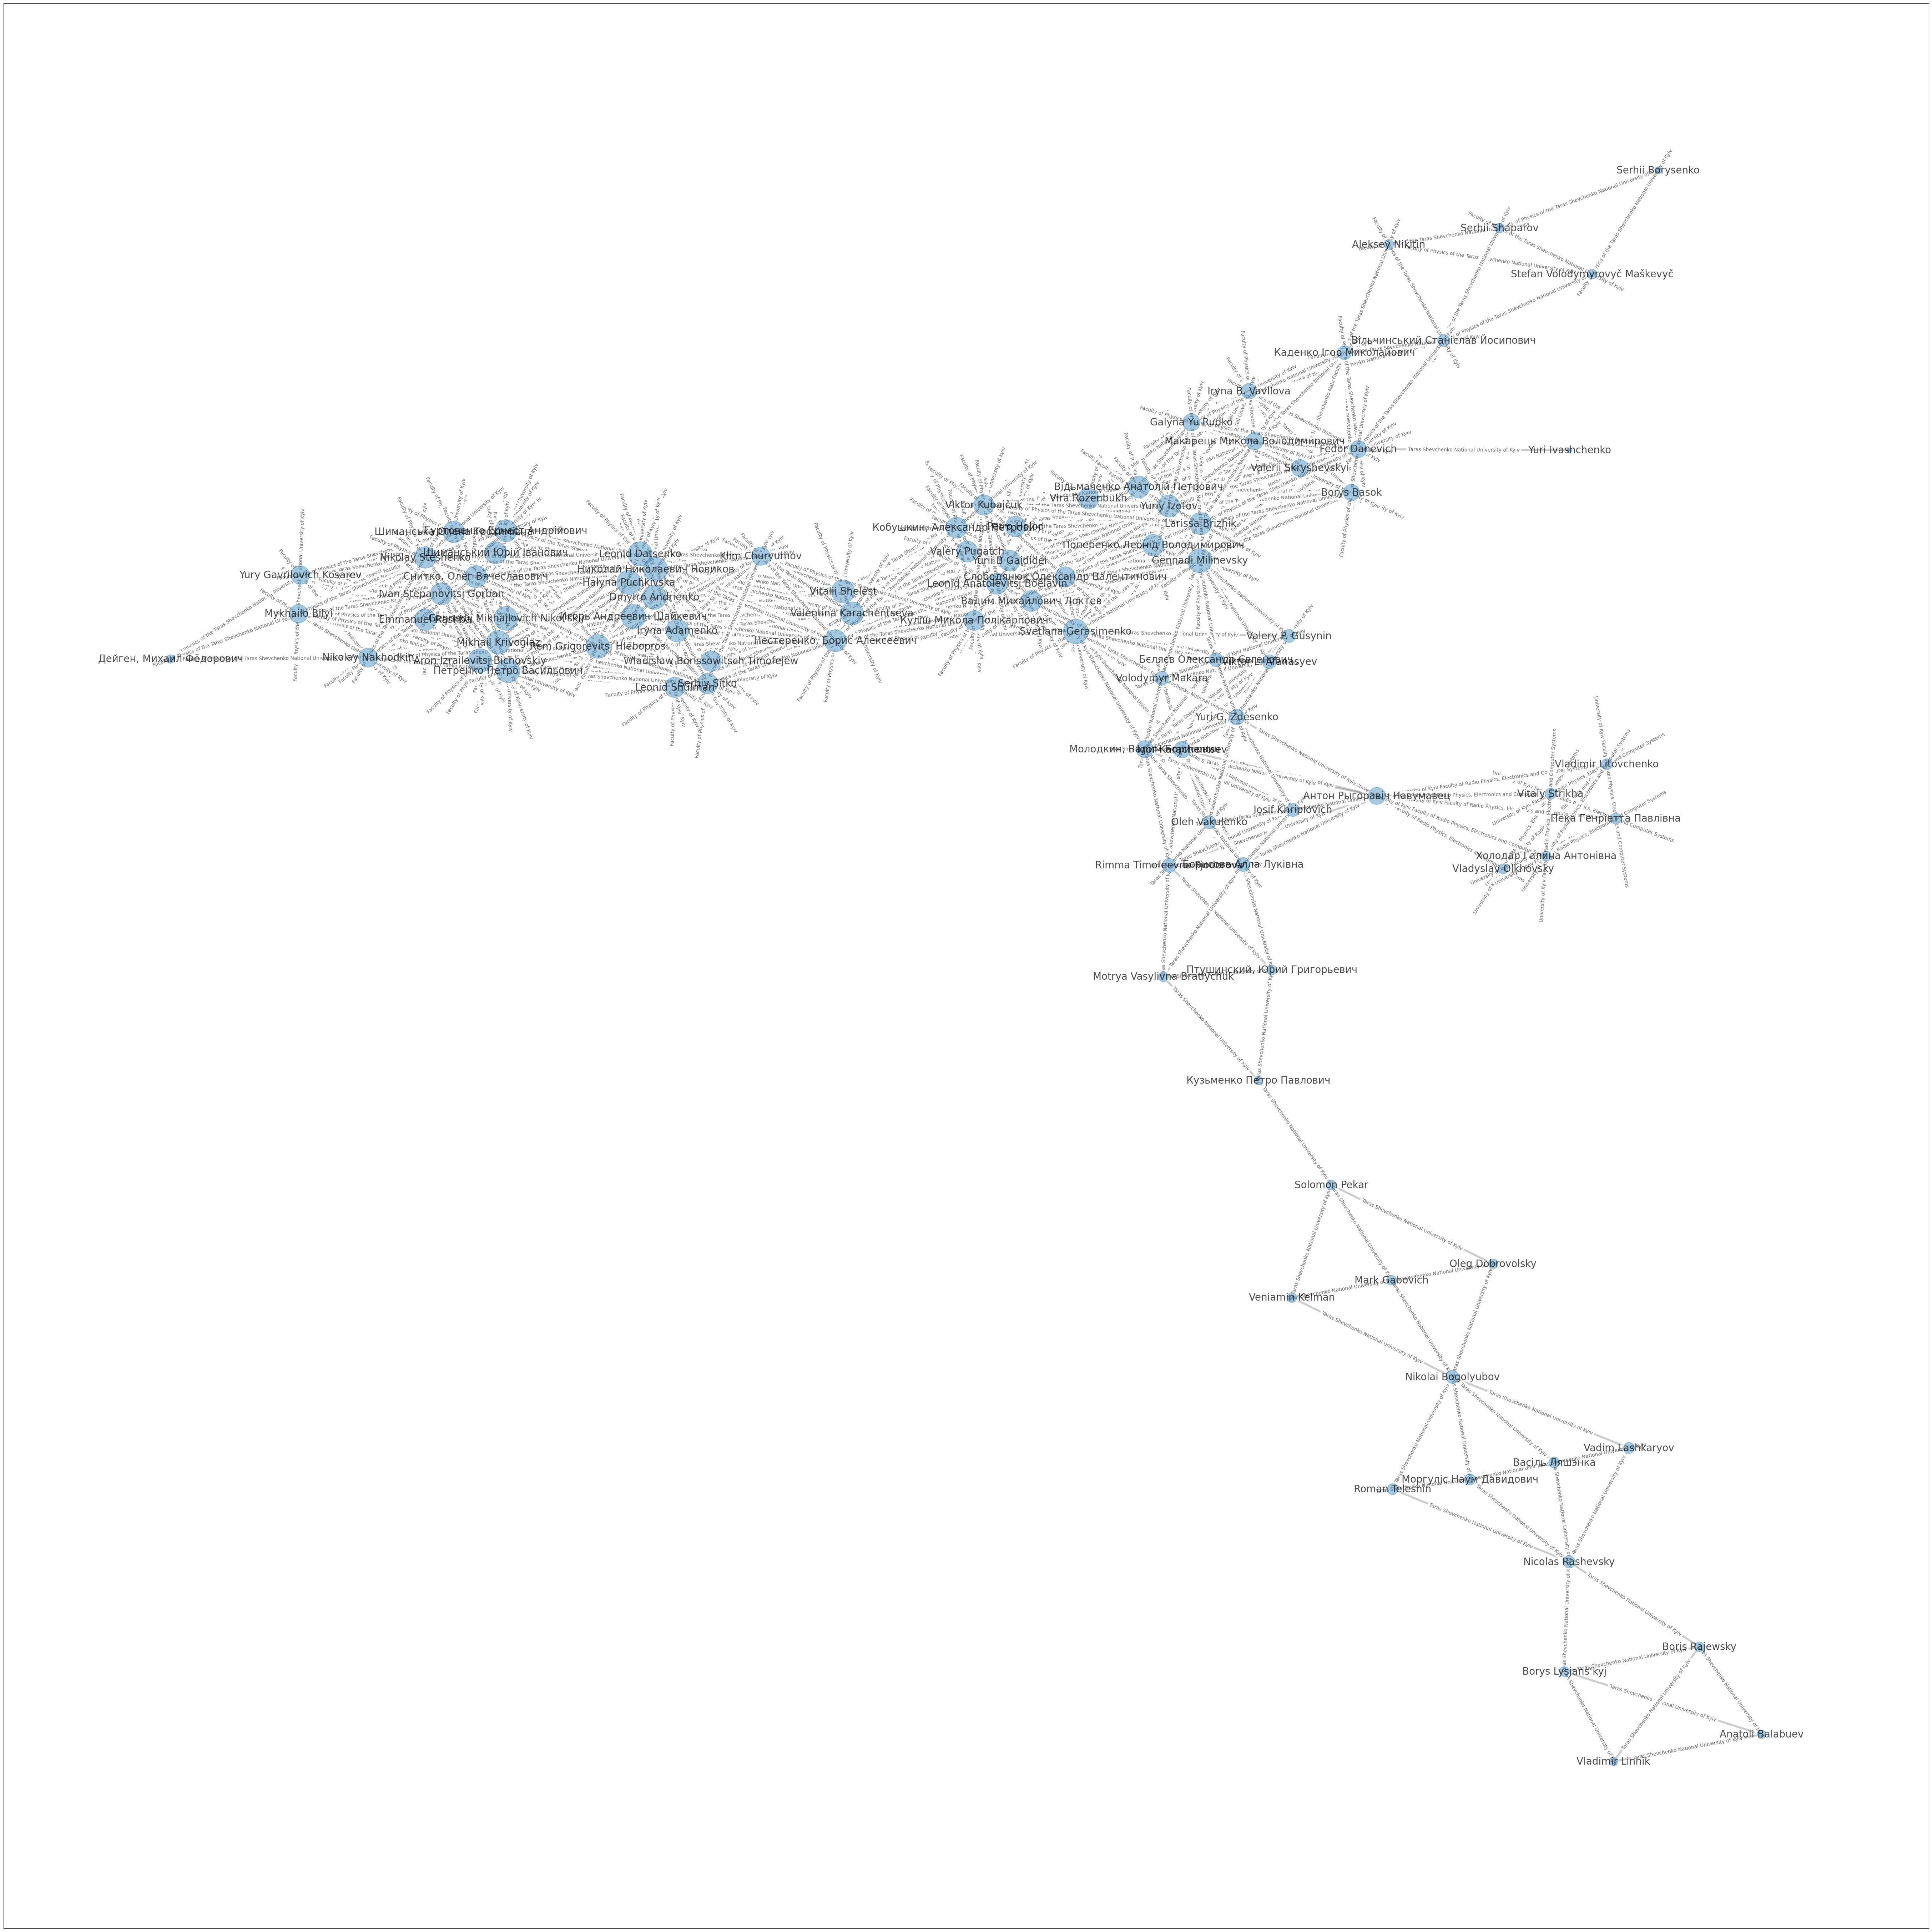

In [442]:
### 



# print(list(g.nodes.data())[:3])
# print(list(g.edges.data())[:3])

n_size = np.log(np.sqrt(nx.number_of_nodes(gu)))* 30 #*25

graph_layout = 'kamada_kawai'
n_k = 0.4
sc = 0.02

### Define the layout, i.e. the choice 
# of the algorithm for the representation of the graph.

if graph_layout == 'fruchterman_reingold':
    pos = nx.fruchterman_reingold_layout(gu)
elif graph_layout == 'kamada_kawai':
    pos = nx.kamada_kawai_layout(gu)
elif graph_layout == 'spring_layout':
    pos = nx.spring_layout(g, k = n_k, scale=sc)  
else:
    pos = nx.kamada_kawai_layout(gu)


# https://networkx.org/documentation/stable/reference/drawing.html
plt.figure(figsize = (n_size,n_size))

node_size = [d[1]*100 for d in nx.degree(gu)]
node_labels = dict([tuple(( n[0] , n[1]['label'] ))for n in gu.nodes.data()])
#print(node_labels)
edge_labels = {e: gu.get_edge_data(e[0], e[1])["orgsLabels"] for e in gu.edges()}
#print(edge_labels)


### On représente successivement les différentes sommets et arêtes,
# puis on ajoute les labels
nx.draw_networkx_nodes(gu, pos,  node_size=node_size, alpha=0.4)
nx.draw_networkx_edges(gu, pos, label=edge_labels, width=4, alpha=0.2) # edgelist=ln, edge_color=c, 
nx.draw_networkx_labels(gu, pos, labels=node_labels, alpha=0.7, font_size=20)
nx.draw_networkx_edge_labels(gu, pos=pos, edge_labels=edge_labels, alpha=0.6)

### On peut augmenter ou diminuer ce paramètre pour ajuster le graphe
plt.tight_layout(pad=50)
#plt.savefig('images/small_bipartite_component.svg')
plt.show()


### Explore with Gephi online

* export the graph in the Gephi format
* explore it uploading the file into the [Gephi Web User Interface](https://lite.gephi.org)

In [443]:
### Graph to heavy to use Gephy online
nx.write_gexf(gu, f"da_graphs/{variable_name}.gexf")

### Main component

In [444]:
### 
li = [0]    
ll = [list(perS[i[0]].nodes.data()) for i in ln if i[0] in li]

In [445]:

# Display variable

variable_name = 'edu_0'

globals()[variable_name] = nx.Graph()

gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    gu = nx.union(gu, perS[i])
naf.basic_graph_properties(gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 11441,
 'number_of_edges': 149316,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.0022816358538760425}


In [ ]:
### Graph to heavy to use Gephy online

# BEWARE : these can be very heavy graphs and shold not be committed to GitHub!!!

###nx.write_gexf(gu, f"da_graphs/{variable_name}.gexf")

In [446]:
pprint.pprint(list(gu.nodes.data())[2:4])

[('http://www.wikidata.org/entity/Q102931598',
  {'birthYear': 1924,
   'coded_country': 'Germany',
   'label': 'Alfred Reule',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q118363',
  {'birthYear': 1931,
   'coded_country': 'Germany',
   'label': 'Wolfgang Demtröder',
   'periodsActivity': '1976-2000'})]


### Centrality distributions

#### Degree centrality

In [447]:
### Add degree centrality to nodes
degree = dict([(d[0], {'degree': d[1]}) for d in nx.degree(gu)])
nx.set_node_attributes(gu, degree)
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000193',
  {'birthYear': 1929,
   'coded_country': 'Germany',
   'degree': 11,
   'label': 'Hans Elsässer',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q100212',
  {'birthYear': 1933,
   'coded_country': 'Germany',
   'degree': 29,
   'label': 'Peter Kramer',
   'periodsActivity': '1976-2000'})]


In [448]:
print(pd.Series([d[1] for d in nx.degree(gu)]).describe())

count    11441.000000
mean        26.101914
std         27.159946
min          1.000000
25%          7.000000
50%         16.000000
75%         37.000000
max        206.000000
dtype: float64


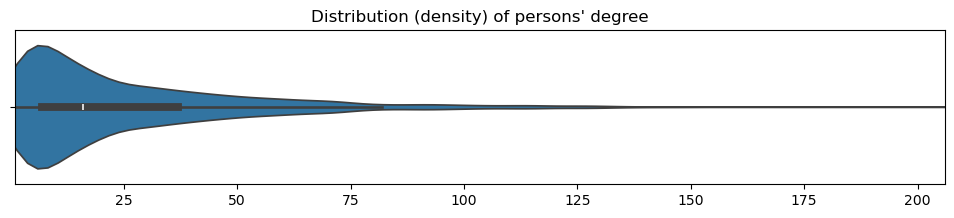

In [449]:
# Plot the distribution of degree centrality density

degree=[d[1] for d in nx.degree(gu)]

min_val = min(degree)
max_val = max(degree)

plt.figure(figsize=(12, 2))
ax = sns.violinplot(data=degree, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of persons\' degree')
plt.show()

In [477]:
threshold = 50
filtered_nodes = [
    (node, data) for node, data in gu.nodes(data=True) 
    if data.get('degree', 0) > threshold
]
print(len(filtered_nodes))

1760


In [478]:
pprint.pprint(filtered_nodes[:2])

[('http://www.wikidata.org/entity/Q100153910',
  {'betweenness': 0.0034642794452317298,
   'birthYear': 1924,
   'coded_country': 'Austria Hungary',
   'degree': 76,
   'eigenvector': 2.96031511958742e-05,
   'label': 'Frank J. Blatt',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q102119328',
  {'betweenness': 0.0014399930716308092,
   'birthYear': 1922,
   'coded_country': 'United States Can.',
   'degree': 69,
   'eigenvector': 2.601912451081194e-05,
   'label': 'Gordon Lee Brownell',
   'periodsActivity': '1951-1975'})]


In [479]:
df_filtered_nodes = pd.DataFrame([
    {'id': node, **attrs}
    for node, attrs in filtered_nodes
])

df_filtered_nodes.sort_values(by='degree', ascending=False).iloc[:10]

,id,label,periodsActivity,coded_country,birthYear,degree,eigenvector,betweenness
1034,http://www.wikidata.org/entity/Q16510526,Anatoly Sukhorukov,1976-2000,Russian Federation,1935,206,0.100090,0.004027
601,http://www.wikidata.org/entity/Q1819421,Leonid Keldysh,1976-2000,Russian Federation,1931,203,0.109647,0.002178
1038,http://www.wikidata.org/entity/Q4133492,Yury Gaponov,1976-2000,Russian Federation,1934,203,0.102933,0.002162
632,http://www.wikidata.org/entity/Q4345163,Jurij Nikolajevič Parijskij,1976-2000,Russian Federation,1932,202,0.107746,0.002212
603,http://www.wikidata.org/entity/Q2038350,Roald Sagdeev,1976-2000,Russian Federation,1932,202,0.107746,0.002212
1048,http://www.wikidata.org/entity/Q709201,Aleksandr Skrinsky,1976-2000,Russian Federation,1936,200,0.086860,0.006516
614,http://www.wikidata.org/entity/Q374205,Victor Maslov,1951-1975,Russian Federation,1930,195,0.106460,0.006505
386,http://www.wikidata.org/entity/Q470389,James L. Elliot,1976-2000,United States Can.,1943,189,0.000114,0.004153
458,http://www.wikidata.org/entity/Q29573,Mildred Dresselhaus,1951-1975,United States Can.,1930,186,0.000176,0.005732
404,http://www.wikidata.org/entity/Q710842,John N. Bahcall,1976-2000,United States Can.,1934,185,0.000185,0.004464


#### Eigenvector centrality

In [458]:
### Add eigenvector to nodes

## If error: PowerIterationFailedConvergence: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
# increase number of max iterations
eigenvector = nx.eigenvector_centrality(gu, max_iter=200)
nx.set_node_attributes(gu, eigenvector, 'eigenvector')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000193',
  {'birthYear': 1929,
   'coded_country': 'Germany',
   'degree': 11,
   'eigenvector': 1.2535604303395997e-08,
   'label': 'Hans Elsässer',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q100212',
  {'birthYear': 1933,
   'coded_country': 'Germany',
   'degree': 29,
   'eigenvector': 1.1283347198509943e-07,
   'label': 'Peter Kramer',
   'periodsActivity': '1976-2000'})]


In [459]:
### Plot eigenvector density distribution 
eigenvector_s = pd.Series(list(eigenvector.values()))
stats = eigenvector_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    11441.00000000000000000000
mean         0.00141729872820673818
std          0.00924141093874887229
min          0.00000000000000000000
25%          0.00000000038623825124
50%          0.00000008425306341958
75%          0.00000544289304563076
max          0.10964651192974395055
dtype: object


#### Betweenness centrality

In [460]:
### Add betweenness to nodes
# Parameters for approximation: k=500, seed=42 and speed up

betweenness = nx.betweenness_centrality(gu, k=500, seed=42)
nx.set_node_attributes(gu, betweenness, 'betweenness')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000193',
  {'betweenness': 1.4699471223515558e-05,
   'birthYear': 1929,
   'coded_country': 'Germany',
   'degree': 11,
   'eigenvector': 1.2535604303395997e-08,
   'label': 'Hans Elsässer',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q100212',
  {'betweenness': 0.003731792701359664,
   'birthYear': 1933,
   'coded_country': 'Germany',
   'degree': 29,
   'eigenvector': 1.1283347198509943e-07,
   'label': 'Peter Kramer',
   'periodsActivity': '1976-2000'})]


In [461]:
### Plot betweenness density distribution 
betweenness_s = pd.Series(list(betweenness.values()))
stats = betweenness_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    11441.00000000000000000000
mean         0.00062955181238029379
std          0.00176960565143412544
min          0.00000000000000000000
25%          0.00001501824758665449
50%          0.00013035756547332680
75%          0.00052187247855583693
max          0.06386323765389231855
dtype: object


In [465]:
stored_graph='da_graphs/gr_edu_0.pkl'

# Save the graph to a file (compact binary format)
with open(stored_graph, 'wb') as f:
    pickle.dump(gu, f)



In [ ]:
### Load the graph without executing the whole notebook again

stored_graph='da_graphs/gr_edu_0.pkl'
# Load the graph from the file
with open(stored_graph, 'rb') as f:
#    G_loaded = pickle.load(f)

In [ ]:
### Export node attributes to dataframe
nodes_data ={node: gu.nodes[node] for node in gu.nodes}
nodes_df = pd.DataFrame(nodes_data).T
nodes_df.reset_index(inplace=True)
nodes_df.columns = ['personUri', 'label','periodsActivity', 'coded_country', 'birthYear','degree','eigenvector', 'betweenness']
nodes_df.head(2)


,personUri,label,periodsActivity,coded_country,birthYear,degree,eigenvector,betweenness
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1951-1975,Germany,1929,11,0.0,0.000015
1,http://www.wikidata.org/entity/Q100212,Peter Kramer,1976-2000,Germany,1933,29,0.0,0.003732


#### Explore degree centrality on gr_edu

In [469]:
nodes_df.sort_values(by='degree', ascending=False).iloc[30:40]

,personUri,label,periodsActivity,coded_country,birthYear,degree,eigenvector,betweenness
3035,http://www.wikidata.org/entity/Q2664403,Alan Lightman,1976-2000,United States Can.,1948,151,0.000031,0.002764
3574,http://www.wikidata.org/entity/Q4205296,Mikhail Itkis,1976-2000,Russian Federation,1942,150,0.040401,0.00148
3595,http://www.wikidata.org/entity/Q4495047,Vladislav Khalilov,1976-2000,Russian Federation,1942,150,0.040401,0.00148
1227,http://www.wikidata.org/entity/Q1509906,Gerald Guralnik,1976-2000,United States Can.,1936,148,0.000168,0.002875
1241,http://www.wikidata.org/entity/Q19544957,David Latham,1976-2000,United States Can.,1940,148,0.000141,0.003463
1233,http://www.wikidata.org/entity/Q16104868,Gino Claudio Segre,1976-2000,Italy,1938,147,0.000154,0.003976
1225,http://www.wikidata.org/entity/Q1252622,J. J. Sakurai,1976-2000,Japan,1933,146,0.000166,0.0021
718,http://www.wikidata.org/entity/Q193503,Kenneth G. Wilson,1976-2000,United States Can.,1936,146,0.000157,0.002563
744,http://www.wikidata.org/entity/Q5919116,Howard C. Berg,1976-2000,United States Can.,1934,145,0.000169,0.002774
1164,http://www.wikidata.org/entity/Q5628481,H. Pierre Noyes,1951-1975,France,1923,145,0.000103,0.002038


In [ ]:
nodes_df[(nodes_df.label.str.contains('Einstein'))|(nodes_df.label.str.contains('Planck'))|(nodes_df.label.str.contains('Bohr'))]

In [471]:
duckdb.query("""
    SELECT label,degree, birthYear,coded_country,periodsActivity
    FROM nodes_df
    ORDER BY degree DESC
    LIMIT 10
""").to_df()

,label,degree,birthYear,coded_country,periodsActivity
0,Anatoly Sukhorukov,206,1935,Russian Federation,1976-2000
1,Leonid Keldysh,203,1931,Russian Federation,1976-2000
2,Yury Gaponov,203,1934,Russian Federation,1976-2000
3,Roald Sagdeev,202,1932,Russian Federation,1976-2000
4,Jurij Nikolajevič Parijskij,202,1932,Russian Federation,1976-2000
5,Aleksandr Skrinsky,200,1936,Russian Federation,1976-2000
6,Victor Maslov,195,1930,Russian Federation,1951-1975
7,James L. Elliot,189,1943,United States Can.,1976-2000
8,Mildred Dresselhaus,186,1930,United States Can.,1951-1975
9,John N. Bahcall,185,1934,United States Can.,1976-2000


In [476]:
duckdb.query("""
    SELECT label,degree, birthYear,coded_country,periodsActivity
    FROM nodes_df
    WHERE label LIKE '%Einstein%'
    ORDER BY degree DESC
    LIMIT 10
""").to_df()

,label,degree,birthYear,coded_country,periodsActivity
0,Bernhard Caesar Einstein,60,1930,Germany,1951-1975
1,Albert Einstein,15,1879,Germany,1901-1925
2,Hans Albert Einstein,13,1904,Switzerland,1926-1950


In [481]:
gr_edu_degree_1000=nodes_df.sort_values(by='degree', ascending=False).iloc[:1000]
#gr_edu_degree_1000.head(2)
df=gr_edu_degree_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [482]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [484]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 349.25 , dof : 95
p-value : 0.0
Inertia (Phi-square):  0.349
Cramer:  0.264


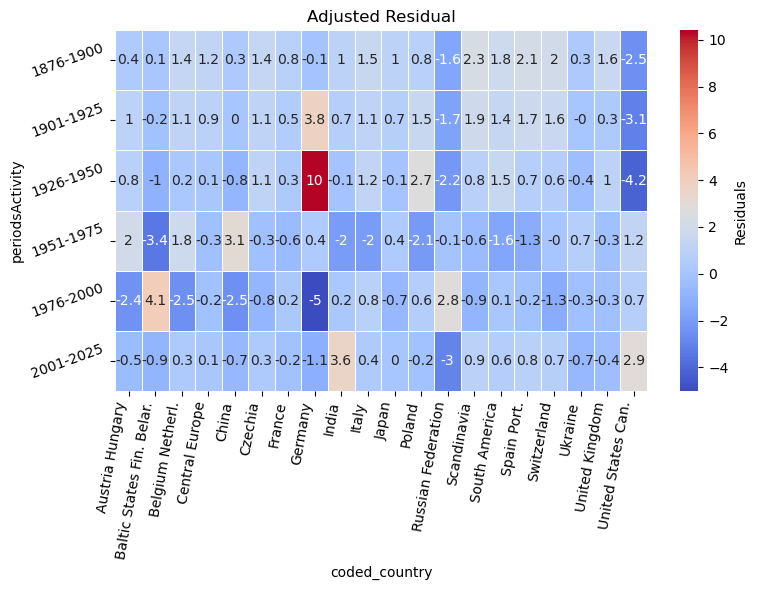

In [ ]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 6))

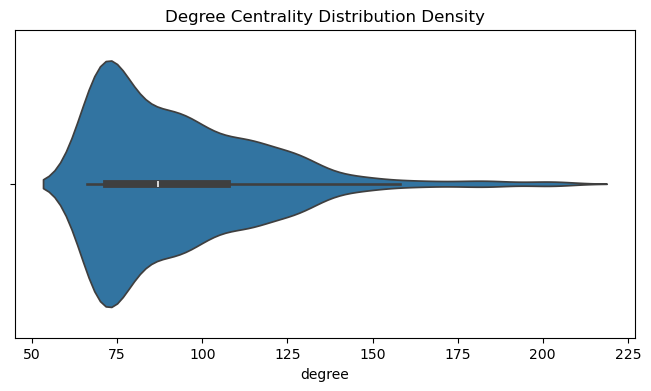

In [486]:
# Plot the distribution of degree centrality density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_edu_degree_1000.degree, orient='h')
plt.title('Degree Centrality Distribution Density')
plt.show()

In [485]:
sg1=gr_edu_degree_1000.merge(df_po[df_po['relationship']=='education'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg1.sort_values(ascending=False)[:20])


organisation_label
Harvard University                          211
MSU Faculty of Physics                      207
Massachusetts Institute of Technology       180
Lomonosov Moscow State University           136
University of California, Berkeley          124
University of Chicago                        69
California Institute of Technology           69
Princeton University                         59
Cornell University                           44
University of Göttingen                      41
Stanford University                          39
University of Tartu                          32
University of Cambridge                      26
Humboldt-Universität zu Berlin               23
Ludwig-Maximilians-Universität München       22
Columbia University                          19
MSU Faculty of Mechanics and Mathematics     18
Harvard College                              14
University of California, Los Angeles        14
University of Michigan                       12
dtype: int64


In [494]:
### Extract the subgraph using only the 1000 nodes
# .copy() creates a new independent graph object
sub_G = gu.subgraph(gr_edu_degree_1000.personUri.tolist()).copy()

# 4. Verify and Export
print(f"Subgraph nodes: {sub_G.number_of_nodes()}")
print(f"Subgraph edges: {sub_G.number_of_edges()}")

graph_address="da_graphs/subgraph_edu_degree_1000.graphml"

# Export directly to Gephi format
nx.write_graphml(sub_G, graph_address)

Subgraph nodes: 1000
Subgraph edges: 33774


#### Explore betweenness on gr_edu

In [495]:
nodes_df.sort_values(by='betweenness', ascending=False).iloc[:20]

,personUri,label,periodsActivity,coded_country,birthYear,degree,eigenvector,betweenness
1828,http://www.wikidata.org/entity/Q8463210,Zhou Yulin,1951-1975,China,1923,84,0.019363,0.063863
1790,http://www.wikidata.org/entity/Q296249,Imre Lakatos,1951-1975,Austria Hungary,1922,110,0.016735,0.0601
2672,http://www.wikidata.org/entity/Q2158609,Robert D. Richtmyer,1951-1975,United States Can.,1910,72,0.000006,0.029721
2732,http://www.wikidata.org/entity/Q91635,Wilhelm Cauer,1926-1950,Germany,1900,119,0.0,0.029399
2637,http://www.wikidata.org/entity/Q20510021,Hovhannes Navakatikyan,1926-1950,Russian Federation,1888,60,0.0,0.028876
1786,http://www.wikidata.org/entity/Q260641,Lénárd Pál,1951-1975,Austria Hungary,1925,110,0.025609,0.025416
5391,http://www.wikidata.org/entity/Q15455688,Leon Takhtajan,1976-2000,Russian Federation,1950,33,0.000031,0.024918
2735,http://www.wikidata.org/entity/Q97326,Hans Kopfermann,1926-1950,Germany,1895,76,0.0,0.023735
862,http://www.wikidata.org/entity/Q43289230,Henryk Szymczak,1976-2000,Poland,1937,123,0.024555,0.022907
2535,http://www.wikidata.org/entity/Q938606,Francis Bitter,1926-1950,United States Can.,1902,81,0.0,0.022605


In [496]:
gr_edu_betweenness_1000=nodes_df.sort_values(by='betweenness', ascending=False).iloc[:1000]
#gr_edu_betweenness_1000.head(2)
df=gr_edu_betweenness_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])

In [497]:
bl.check_chi_square_test_validity(crosstab)
expected=bl.bivariate_stats(crosstab)

Table valid for Chi-square test: False
Chi-square : 374.69 , dof : 133
p-value : 0.0
Inertia (Phi-square):  0.375
Cramer:  0.231


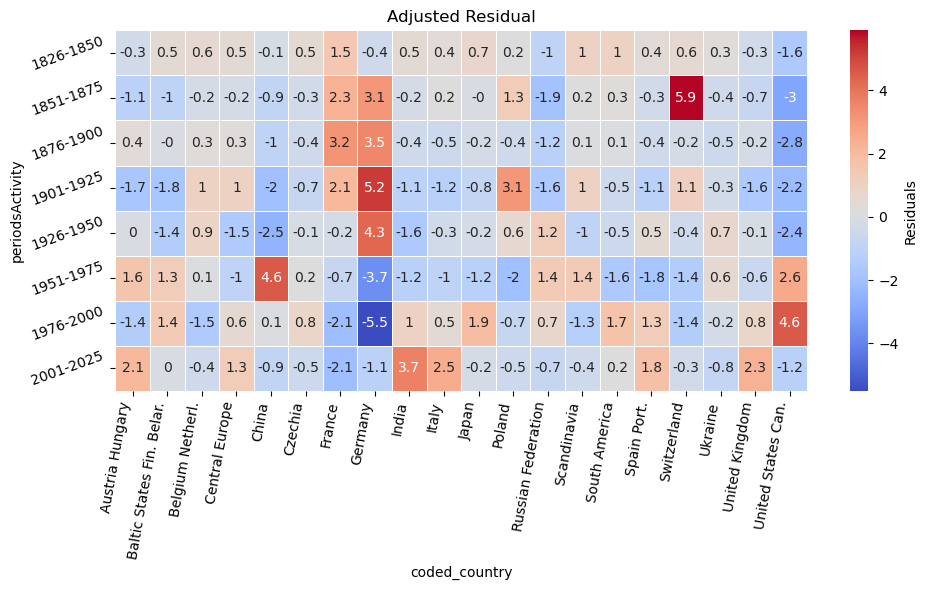

In [498]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 6))

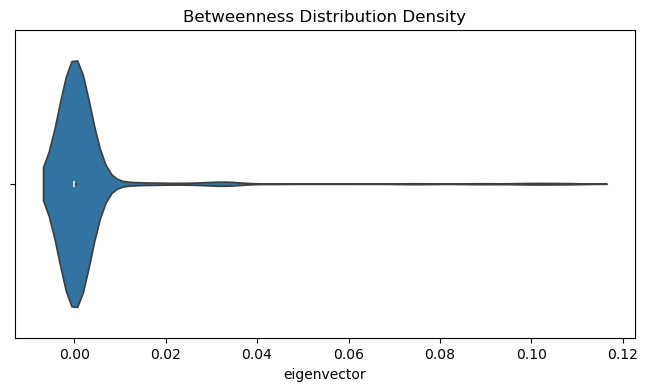

In [499]:
# Plot the distribution of betweenness density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_edu_betweenness_1000.eigenvector, orient='h')
plt.title('Betweenness Distribution Density')
plt.show()

In [500]:
### Organisations where these persons studies
sg1=gr_edu_betweenness_1000.merge(df_po[df_po['relationship']=='education'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg1.sort_values(ascending=False)[:10])


organisation_label
University of Göttingen                   117
Humboldt-Universität zu Berlin            115
Harvard University                        107
Massachusetts Institute of Technology     104
Lomonosov Moscow State University          92
University of Cambridge                    65
University of California, Berkeley         54
Ludwig-Maximilians-Universität München     47
California Institute of Technology         43
University of Paris                        41
dtype: int64


#### Explore eigenvector on gr_edu

In [501]:
nodes_df.sort_values(by='eigenvector', ascending=False).iloc[:5]

,personUri,label,periodsActivity,coded_country,birthYear,degree,eigenvector,betweenness
1779,http://www.wikidata.org/entity/Q1819421,Leonid Keldysh,1976-2000,Russian Federation,1931,203,0.109647,0.002178
1781,http://www.wikidata.org/entity/Q2038350,Roald Sagdeev,1976-2000,Russian Federation,1932,202,0.107746,0.002212
1811,http://www.wikidata.org/entity/Q4345163,Jurij Nikolajevič Parijskij,1976-2000,Russian Federation,1932,202,0.107746,0.002212
1793,http://www.wikidata.org/entity/Q374205,Victor Maslov,1951-1975,Russian Federation,1930,195,0.10646,0.006505
3094,http://www.wikidata.org/entity/Q4133492,Yury Gaponov,1976-2000,Russian Federation,1934,203,0.102933,0.002162


In [502]:
gr_edu_eigenv_1000=nodes_df.sort_values(by='eigenvector', ascending=False).iloc[:1000]
df=gr_edu_eigenv_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [503]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [504]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 141.78 , dof : 39
p-value : 0.0
Inertia (Phi-square):  0.142
Cramer:  0.217


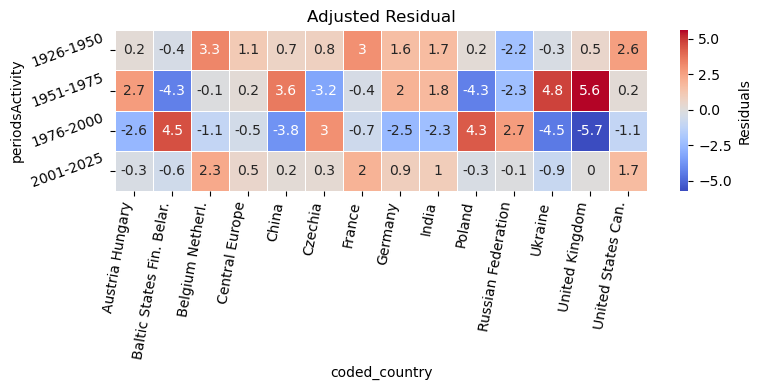

In [505]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 4))

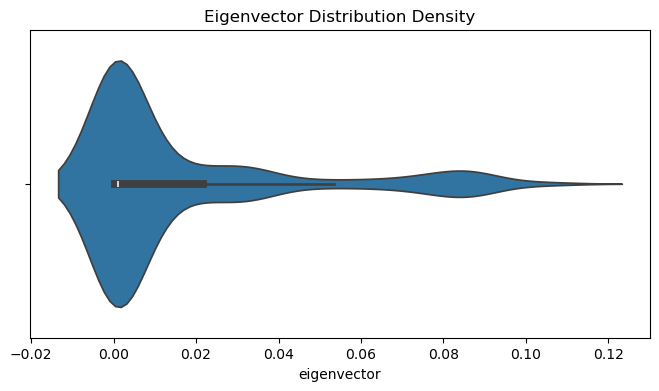

In [506]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_edu_eigenv_1000.eigenvector, orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

In [507]:
sg1=gr_edu_eigenv_1000.merge(df_po[df_po['relationship']=='education'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg1.sort_values(ascending=False)[:10])


organisation_label
MSU Faculty of Physics                      284
Lomonosov Moscow State University           204
University of Tartu                          77
National Research Nuclear University         61
Saint Petersburg State University            60
MSU Faculty of Mechanics and Mathematics     57
Yerevan State University                     51
University of Cambridge                      45
University of Warsaw                         38
National University of Kharkiv               38
dtype: int64


In [511]:
l_nodes=[n for n in gr_edu_eigenv_1000[:100].personUri]
print(l_nodes[:2])

['http://www.wikidata.org/entity/Q1819421', 'http://www.wikidata.org/entity/Q2038350']


In [514]:
### Extract an egograph of the first 100 more central individual (eigenvalue centrality)

# 3. Extract ego networks
# radius=1 includes immediate neighbors; radius=2 includes neighbors of neighbors
ego_networks = [nx.ego_graph(gu, n, radius=1) for n in l_nodes]

# 4. Combine into a single subgraph
combined_ego_graph = nx.compose_all(ego_networks)

# 5. Export to GraphML for Gephi
graph_address='da_graphs/ego_ntwk_eingenvalue_100_edu.graphml'
nx.write_graphml(combined_ego_graph, graph_address)

## Explore the employment relationships graph

### Employment

In [515]:
print(len(gr_empl))

323847


In [516]:
## Provide the data in the format 
# required by Networkx

l = [tuple(
    (e['person_uri_x'], e['person_uri_y'],
     {'orgsUris':e['orgs_uris'], 'orgsLabels':e['orgs_labels'], 'orgsNumber':e['orgs_number'],   
      'periods_x':e['periodsActivity_x'], 'periods_y':e['periodsActivity_y']}
     )) 
     for e in gr_empl.to_dict(orient='records')]
print(len(l))

323847


In [517]:
## Créate the empty graph
G_empl=nx.Graph()

## Add relationships to graph
# Multiple rows between two edges are taken only once
G_empl.add_edges_from(l)

naf.basic_graph_properties(G_empl)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 11809,
 'number_of_edges': 323847,
 '------': '------',
 'is connected': False,
 'components': 127,
 'density': 0.004644943191323691}


#### Add metadata to nodes

In [518]:
df_pm = df_p[['person_uri','labelPer','periodsActivity','coded_country']]
df_pm = df_pm.drop_duplicates()
df_pm.columns=['uri', 'label','periodsActivity','coded_country']
df_pm.head()


,uri,label,periodsActivity,coded_country
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1826-1850,France
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1826-1850,Germany
2,http://www.wikidata.org/entity/Q874465,József Csorba,1826-1850,Ukraine
3,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1826-1850,Germany
4,http://www.wikidata.org/entity/Q22331669,Carlo Brioschi,1826-1850,Italy


In [519]:
df_p.columns

Index(['person_uri', 'labelPer', 'gender', 'birthYear', 'coded_country',
       'periodsActivity'],
      dtype='object')

In [520]:
### Prepare data to add to nodes
# The data must be of type : dictionary, i.e. key:value structure
ln = dict([(e['uri'],
     {'label':e['label'], 'periodsActivity':e['periodsActivity'],
      'coded_country':e['coded_country']}
     ) for e in df_pm.to_dict(orient='records')])
# print(str(l)[:200])

In [521]:

## Add attributes
nx.set_node_attributes(G_empl, ln)
pprint.pprint(list(G_empl.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000934',
  {'coded_country': 'Scandinavia',
   'label': 'Charles Christian Lauritsen',
   'periodsActivity': '1926-1950'}),
 ('http://www.wikidata.org/entity/Q102306320',
  {'coded_country': 'United States Can.',
   'label': 'William Edward Deeds',
   'periodsActivity': '1951-1975'})]


#### Components

In [522]:
### Create a list of graphs, one per component
perS = [G_empl.subgraph(c).copy() for c in nx.connected_components(G_empl)]

### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
ln = sorted([[i,len(s.nodes)] for i,s in enumerate(perS)], key = lambda row: row[1], reverse=True)
print(ln[:5])

### Again we observe that there is a big connected graphe 
# and a multitude of small graphs

[[0, 11474], [1, 13], [12, 11], [11, 9], [8, 7]]


#### Main component

In [523]:
### 
li = [0]    # [15, 33, 30]
ll = [list(perS[i[0]].nodes.data()) for i in ln if i[0] in li ]
#pprint.pprint(str(ll)[:300])

In [524]:

# Display variable

variable_name = 'empl_0'

globals()[variable_name] = nx.Graph()

gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    gu = nx.union(gu, perS[i])
naf.basic_graph_properties(gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 11474,
 'number_of_edges': 323480,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.004914570743588319}


In [525]:
### Graph to heavy to use Gephy online
# nx.write_gexf(gu, f"da_graphs/{variable_name}.gexf")

In [526]:
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000934',
  {'coded_country': 'Scandinavia',
   'label': 'Charles Christian Lauritsen',
   'periodsActivity': '1926-1950'}),
 ('http://www.wikidata.org/entity/Q102306320',
  {'coded_country': 'United States Can.',
   'label': 'William Edward Deeds',
   'periodsActivity': '1951-1975'})]


### Centrality distributions

#### Degree centrality

In [527]:
### Add degree centrality to nodes
degree = dict([(d[0], {'degree': d[1]}) for d in nx.degree(gu)])
nx.set_node_attributes(gu, degree)
pprint.pprint(list(gu.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000934',
  {'coded_country': 'Scandinavia',
   'degree': 63,
   'label': 'Charles Christian Lauritsen',
   'periodsActivity': '1926-1950'}),
 ('http://www.wikidata.org/entity/Q102306320',
  {'coded_country': 'United States Can.',
   'degree': 131,
   'label': 'William Edward Deeds',
   'periodsActivity': '1951-1975'})]


In [528]:
### Degree centrality distribution
print(pd.Series([d[1] for d in nx.degree(gu)]).describe())

count    11474.000000
mean        56.384870
std         65.868337
min          1.000000
25%         12.000000
50%         33.000000
75%         75.000000
max        580.000000
dtype: float64


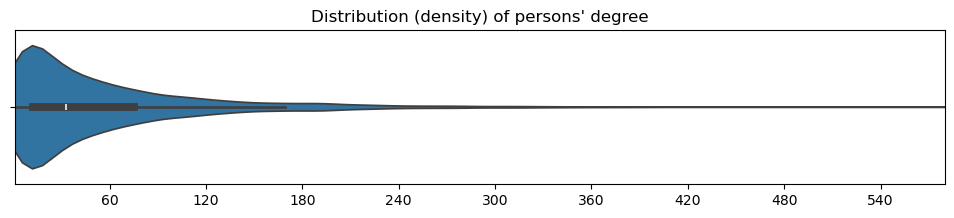

In [529]:
# Plot the distribution of eigenvector density

degree=[d[1] for d in nx.degree(gu)]

min_val = min(degree)
max_val = max(degree)

plt.figure(figsize=(12, 2))
ax = sns.violinplot(data=degree, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of persons\' degree')
plt.show()

In [530]:
threshold = 100
filtered_nodes = [
    (node, data) for node, data in gu.nodes(data=True) 
    if data.get('degree', 0) > threshold
]

In [531]:
print(len(filtered_nodes))

1973


In [532]:
pprint.pprint(filtered_nodes[:2])

[('http://www.wikidata.org/entity/Q102306320',
  {'coded_country': 'United States Can.',
   'degree': 131,
   'label': 'William Edward Deeds',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q109587870',
  {'coded_country': 'United States Can.',
   'degree': 107,
   'label': 'J. Harold Wayland',
   'periodsActivity': '1951-1975'})]


In [533]:
df_filtered_nodes = pd.DataFrame([
    {'id': node, **attrs}
    for node, attrs in filtered_nodes
])

df_filtered_nodes.sort_values(by='degree', ascending=False).iloc[:20]

,id,label,periodsActivity,coded_country,degree
130,http://www.wikidata.org/entity/Q1560329,Robert J. Birgeneau,1976-2000,United States Can.,580
149,http://www.wikidata.org/entity/Q184980,Thomas Kuhn,1951-1975,United States Can.,578
360,http://www.wikidata.org/entity/Q1901962,Marlan Scully,1976-2000,United States Can.,539
488,http://www.wikidata.org/entity/Q948991,Elliott Waters Montroll,1951-1975,United States Can.,531
134,http://www.wikidata.org/entity/Q1620293,Hirosi Ooguri,2001-2025,Japan,525
741,http://www.wikidata.org/entity/Q2149938,Richard Keith Ellis,1976-2000,United Kingdom,523
606,http://www.wikidata.org/entity/Q964122,Geoffrey West,1976-2000,United Kingdom,508
97,http://www.wikidata.org/entity/Q74041,Hans-Joachim Bremermann,1951-1975,Germany,507
181,http://www.wikidata.org/entity/Q353407,Isadore Singer,1951-1975,United States Can.,506
185,http://www.wikidata.org/entity/Q391237,John Hopfield,1976-2000,United States Can.,500


In [534]:
sg_edu_degree=df_filtered_nodes.sort_values(by='degree', ascending=False).iloc[:20]\
    .merge(df_po[df_po['relationship']=='employment'],
                        left_on='id',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg1.sort_values(ascending=False)[:20])


organisation_label
MSU Faculty of Physics                                       284
Lomonosov Moscow State University                            204
University of Tartu                                           77
National Research Nuclear University                          61
Saint Petersburg State University                             60
MSU Faculty of Mechanics and Mathematics                      57
Yerevan State University                                      51
University of Cambridge                                       45
University of Warsaw                                          38
National University of Kharkiv                                38
Eötvös Loránd University                                      29
Tbilisi State University                                      24
Moscow Institute of Physics and Technology                    24
Moscow Power Engineering Institute                            24
Charles University                                            21
Novosi

In [535]:
gr_empl.head()

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,periodsActivity_x,periodsActivity_y
0,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q102306320,California Institute of Technology,1,http://www.wikidata.org/entity/Q161562,1926-1950,1951-1975
1,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q109587870,California Institute of Technology,1,http://www.wikidata.org/entity/Q161562,1926-1950,1951-1975
2,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q111028460,California Institute of Technology,1,http://www.wikidata.org/entity/Q161562,1926-1950,1951-1975
3,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q11171244,California Institute of Technology,1,http://www.wikidata.org/entity/Q161562,1926-1950,1926-1950
4,http://www.wikidata.org/entity/Q1000934,http://www.wikidata.org/entity/Q112377853,California Institute of Technology,1,http://www.wikidata.org/entity/Q161562,1926-1950,1951-1975


#### Eigenvector centrality

In [536]:
### Add eigenvector to nodes

## If error: PowerIterationFailedConvergence: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
# increase number of max iterations
eigenvector = nx.eigenvector_centrality(gu, max_iter=200)
nx.set_node_attributes(gu, eigenvector, 'eigenvector')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000934',
  {'coded_country': 'Scandinavia',
   'degree': 63,
   'eigenvector': 0.005768477966221486,
   'label': 'Charles Christian Lauritsen',
   'periodsActivity': '1926-1950'}),
 ('http://www.wikidata.org/entity/Q102306320',
  {'coded_country': 'United States Can.',
   'degree': 131,
   'eigenvector': 0.013709981785004122,
   'label': 'William Edward Deeds',
   'periodsActivity': '1951-1975'})]


In [537]:
### Plot eigenvector density distribution 
eigenvector_s = pd.Series(list(eigenvector.values()))
stats = eigenvector_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    11474.00000000000000000000
mean         0.00321133678274473445
std          0.00876627504638946564
min          0.00000000000000771986
25%          0.00002884611640197828
50%          0.00025959734384957628
75%          0.00160019740616199968
max          0.10430375358542517961
dtype: object


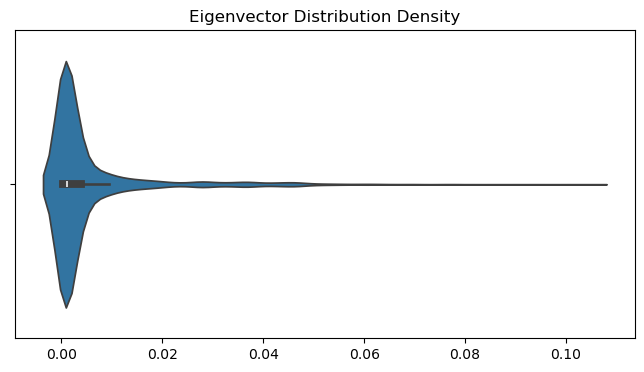

In [538]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=eigenvector_s[eigenvector_s> 0.00013610493515402787], orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

#### Betweenness centrality

In [547]:
### Add betweenness to nodes
# Parameters for approximation: k=500, seed=42 and speed up

betweenness = nx.betweenness_centrality(gu, k=500, seed=42)
nx.set_node_attributes(gu, betweenness, 'betweenness')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000934',
  {'betweenness': 4.867413878558573e-06,
   'coded_country': 'Scandinavia',
   'degree': 63,
   'eigenvector': 0.005768477966221486,
   'label': 'Charles Christian Lauritsen',
   'periodsActivity': '1926-1950'}),
 ('http://www.wikidata.org/entity/Q102306320',
  {'betweenness': 0.00010089148537552659,
   'coded_country': 'United States Can.',
   'degree': 131,
   'eigenvector': 0.013709981785004122,
   'label': 'William Edward Deeds',
   'periodsActivity': '1951-1975'})]


In [548]:
### Plot betweenness density distribution 
betweenness_s = pd.Series(list(betweenness.values()))
stats = betweenness_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    11474.00000000000000000000
mean         0.00023328557096213156
std          0.00075854964289228364
min          0.00000000000000000000
25%          0.00000092515255428894
50%          0.00001465304870836577
75%          0.00013009684895544626
max          0.01787985091753975173
dtype: object


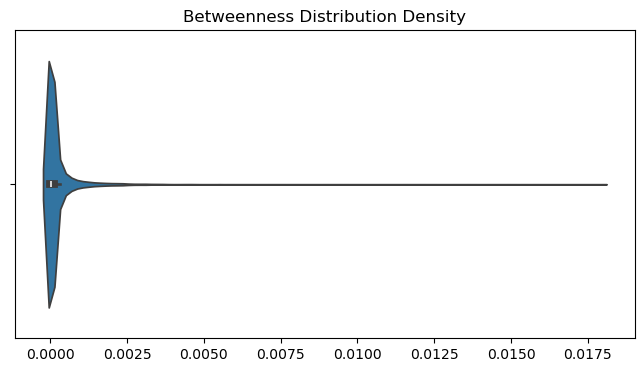

In [549]:
# Plot the distribution of eigenbetweenness vector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=betweenness_s, orient='h')
plt.title('Betweenness Distribution Density')
plt.show()

In [550]:
### Export node attributes to dataframe
nodes_data ={node: gu.nodes[node] for node in gu.nodes}
nodes_df_empl = pd.DataFrame(nodes_data).T
nodes_df_empl.reset_index(inplace=True)
nodes_df_empl.columns = ['personUri', 'label','periodsActivity', 'coded_country','degree','eigenvector', 'betweenness']
nodes_df_empl.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
0,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1926-1950,Scandinavia,63,0.005768,0.000005
1,http://www.wikidata.org/entity/Q102306320,William Edward Deeds,1951-1975,United States Can.,131,0.01371,0.000101


#### Explore eigenvector on gr_empl

In [551]:
nodes_df_empl.sort_values(by='eigenvector', ascending=False).iloc[:5]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
221,http://www.wikidata.org/entity/Q184980,Thomas Kuhn,1951-1975,United States Can.,578,0.104304,0.001828
540,http://www.wikidata.org/entity/Q1901962,Marlan Scully,1976-2000,United States Can.,539,0.090018,0.003792
855,http://www.wikidata.org/entity/Q325584,George B. Field,1951-1975,United States Can.,469,0.087348,0.000986
253,http://www.wikidata.org/entity/Q353407,Isadore Singer,1951-1975,United States Can.,506,0.080022,0.002655
202,http://www.wikidata.org/entity/Q1560329,Robert J. Birgeneau,1976-2000,United States Can.,580,0.07891,0.005851


In [552]:
gr_empl_eigenv_1000=nodes_df_empl.sort_values(by='eigenvector', ascending=False).iloc[:1000]
gr_empl_eigenv_1000.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
221,http://www.wikidata.org/entity/Q184980,Thomas Kuhn,1951-1975,United States Can.,578,0.104304,0.001828
540,http://www.wikidata.org/entity/Q1901962,Marlan Scully,1976-2000,United States Can.,539,0.090018,0.003792


In [553]:
df=gr_empl_eigenv_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [554]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [555]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 167.79 , dof : 76
p-value : 0.0
Inertia (Phi-square):  0.168
Cramer:  0.205


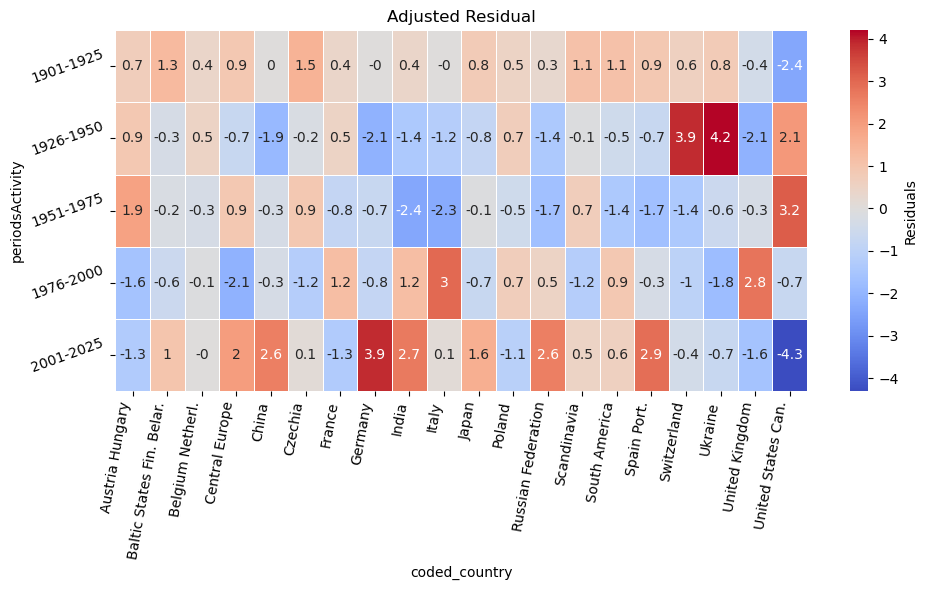

In [556]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 6))

In [557]:
crosstab

periodsActivity,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025
coded_country,,,,,
Austria Hungary,1,6,18,11,3
Baltic States Fin. Belar.,0,0,2,2,2
Belgium Netherl.,0,3,6,8,3
Central Europe,0,0,5,1,4
China,0,0,11,14,11
Czechia,0,0,3,1,1
France,0,3,5,11,1
Germany,1,3,22,28,23
India,0,0,2,12,8


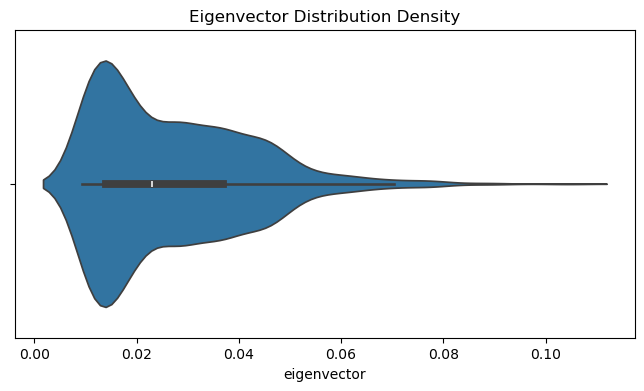

In [558]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_empl_eigenv_1000.eigenvector, orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

In [559]:
sg2=gr_empl_eigenv_1000.merge(df_po[df_po['relationship']=='employment'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg2.sort_values(ascending=False)[:20])


organisation_label
Massachusetts Institute of Technology    218
Harvard University                       211
University of California, Berkeley       186
Princeton University                     144
California Institute of Technology       137
Stanford University                      106
University of Chicago                     71
Columbia University                       56
Cornell University                        46
CERN                                      46
Leiden University                         44
Bell Labs                                 36
University of California, San Diego       35
Institute for Advanced Study              28
Los Alamos National Laboratory            27
University of Michigan                    27
Lawrence Berkeley National Laboratory     23
University of California, Los Angeles     23
University of Arizona                     21
University of Texas at Austin             21
dtype: int64


#### Explore betweenness on gr_empl

In [560]:
nodes_df_empl.sort_values(by='betweenness', ascending=False).iloc[:5]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
971,http://www.wikidata.org/entity/Q465488,Leopold Infeld,1926-1950,Poland,237,0.006694,0.01788
2456,http://www.wikidata.org/entity/Q927125,Nicolas Rashevsky,1926-1950,Ukraine,205,0.011663,0.015612
1853,http://www.wikidata.org/entity/Q551204,Stephen Timoshenko,1901-1925,Ukraine,179,0.00377,0.014691
3553,http://www.wikidata.org/entity/Q188128,Alexei Abrikosov,1951-1975,Russian Federation,409,0.007783,0.014664
1514,http://www.wikidata.org/entity/Q8753,Enrico Fermi,1926-1950,Italy,354,0.018749,0.013424


In [561]:
gr_empl_betweenness_1000=nodes_df_empl.sort_values(by='betweenness', ascending=False).iloc[:1000]
gr_empl_betweenness_1000.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
971,http://www.wikidata.org/entity/Q465488,Leopold Infeld,1926-1950,Poland,237,0.006694,0.01788
2456,http://www.wikidata.org/entity/Q927125,Nicolas Rashevsky,1926-1950,Ukraine,205,0.011663,0.015612


In [562]:
df=gr_empl_betweenness_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [563]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [564]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 229.15 , dof : 114
p-value : 0.0
Inertia (Phi-square):  0.229
Cramer:  0.195


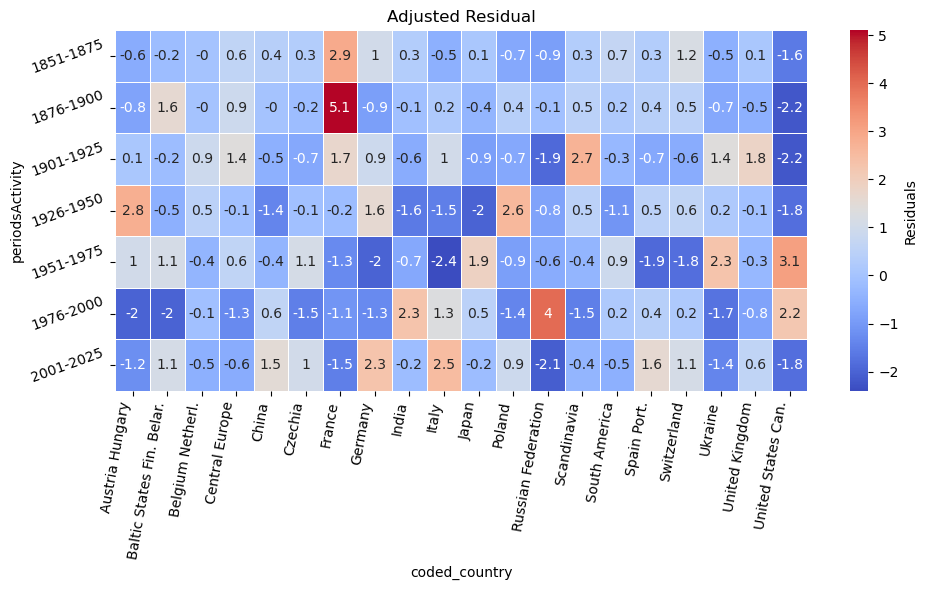

In [565]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 6))

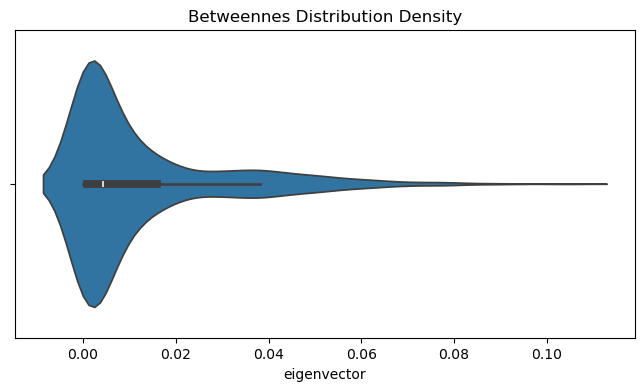

In [566]:
# Plot the distribution of betweenness density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_empl_betweenness_1000.eigenvector, orient='h')
plt.title('Betweennes Distribution Density')
plt.show()

In [567]:
sg2=gr_empl_betweenness_1000.merge(df_po[df_po['relationship']=='employment'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg2.sort_values(ascending=False)[:20])


organisation_label
Harvard University                            89
University of California, Berkeley            72
CERN                                          70
Massachusetts Institute of Technology         69
University of Chicago                         60
Lomonosov Moscow State University             59
Leiden University                             58
Princeton University                          57
Humboldt-Universität zu Berlin                47
University of Göttingen                       46
California Institute of Technology            45
University of Cambridge                       44
Ludwig-Maximilians-Universität München        39
Stanford University                           39
Columbia University                           37
University of Michigan                        32
Joint Institute for Nuclear Research          29
Cornell University                            28
Moscow Institute of Physics and Technology    28
ETH Zurich                                    26
d

In [573]:
l_nodes=[n for n in gr_empl_betweenness_1000[:30].personUri]
print(l_nodes[:2])

['http://www.wikidata.org/entity/Q465488', 'http://www.wikidata.org/entity/Q927125']


In [575]:
### Extract an egograph of the first 100 more central individual (eigenvalue centrality)

# Extract ego networks
# radius=1 includes immediate neighbors; radius=2 includes neighbors of neighbors
ego_networks = [nx.ego_graph(gu, n, radius=1) for n in l_nodes]

# Combine into a single subgraph
combined_ego_graph = nx.compose_all(ego_networks)

# 5. Export to GraphML for Gephi
graph_address='da_graphs/ego_ntwk_betweennes_100_empl_radius_1.graphml'
nx.write_graphml(combined_ego_graph, graph_address)

## Explore the membership relationships graph

In [577]:
gr_memb.head(2)

,person_uri_x,person_uri_y,periodsActivity_x,year_begin_x,year_end_x,year_begin_y,year_end_y,periodsActivity_y,organisation_label,organisation_uri,number
0,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q100216,1951-1975,1969,1994,1989,2014,1976-2000,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q543804,1
1,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q102226864,1951-1975,1969,1994,1962,1987,1951-1975,German Academy of Sciences Leopoldina,http://www.wikidata.org/entity/Q543804,1


In [587]:
## Provide the data in the format 
# required by Networkx

l = [tuple(
    (e['person_uri_x'], e['person_uri_y'],
     {'orgsUris':e['orgs_uris'], 'orgsLabels':e['orgs_labels'], 'orgsNumber':e['orgs_number'],   
      'periods_x':e['periodsActivity_x'], 'periods_y':e['periodsActivity_y']}
     )) 
     for e in gr_memb.to_dict(orient='records')]
print(len(l))

997706


In [588]:
## Créate the empty graph
G_memb=nx.Graph()

## Add relationships to graph
# Multiple rows between two edges are taken only once
G_memb.add_edges_from(l)

naf.basic_graph_properties(G_memb)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 6506,
 'number_of_edges': 997706,
 '------': '------',
 'is connected': False,
 'components': 31,
 'density': 0.04714886252930837}


#### Add metadata to nodes

In [590]:
df_pm = df_p[['person_uri','labelPer','periodsActivity','coded_country']]
df_pm = df_pm.drop_duplicates()
df_pm.columns=['uri', 'label','periodsActivity','coded_country']
df_pm.head()


,uri,label,periodsActivity,coded_country
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1826-1850,France
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1826-1850,Germany
2,http://www.wikidata.org/entity/Q874465,József Csorba,1826-1850,Ukraine
3,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1826-1850,Germany
4,http://www.wikidata.org/entity/Q22331669,Carlo Brioschi,1826-1850,Italy


In [591]:
### Prepare data to add to nodes
# The data must be of type : dictionary, i.e. key:value structure
ln = dict([(e['uri'],
     {'label':e['label'], 'periodsActivity':e['periodsActivity'],
      'coded_country':e['coded_country']}
     ) for e in df_pm.to_dict(orient='records')])
# print(str(l)[:200])

In [592]:

## Add attributes
nx.set_node_attributes(G_memb, ln)
pprint.pprint(list(G_memb.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000193',
  {'coded_country': 'Germany',
   'label': 'Hans Elsässer',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q100216',
  {'coded_country': 'Germany',
   'label': 'Willi Kalender',
   'periodsActivity': '1976-2000'})]


#### Components

In [593]:
### Create a list of graphs, one per component
perS = [G_memb.subgraph(c).copy() for c in nx.connected_components(G_memb)]

### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
ln = sorted([[i,len(s.nodes)] for i,s in enumerate(perS)], key = lambda row: row[1], reverse=True)
print(ln[:5])

### Again we observe that there is a big connected graphe 
# and a multitude of small graphs

[[0, 6434], [9, 6], [21, 5], [2, 3], [3, 3]]


#### Main component

In [594]:
### 
li = [0]    # [15, 33, 30]
ll = [list(perS[i[0]].nodes.data()) for i in ln if i[0] in li ]
#pprint.pprint(str(ll)[:300])

In [595]:

# Display variable

variable_name = 'memb_0'

globals()[variable_name] = nx.Graph()

gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    gu = nx.union(gu, perS[i])
naf.basic_graph_properties(gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 6434,
 'number_of_edges': 997648,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.048207290653990605}


In [596]:
### Graph to heavy to use Gephy online
# nx.write_gexf(gu, f"da_graphs/{variable_name}.gexf")

In [597]:
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000193',
  {'coded_country': 'Germany',
   'label': 'Hans Elsässer',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q100216',
  {'coded_country': 'Germany',
   'label': 'Willi Kalender',
   'periodsActivity': '1976-2000'})]


In [598]:
### Add degree centrality to nodes
degree = dict([(d[0], {'degree': d[1]}) for d in nx.degree(gu)])
nx.set_node_attributes(gu, degree)
pprint.pprint(list(gu.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000193',
  {'coded_country': 'Germany',
   'degree': 227,
   'label': 'Hans Elsässer',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q100216',
  {'coded_country': 'Germany',
   'degree': 167,
   'label': 'Willi Kalender',
   'periodsActivity': '1976-2000'})]


### Degree distribution

count    6434.000000
mean      310.117501
std       319.400594
min         1.000000
25%        58.000000
50%       189.000000
75%       505.000000
max      2086.000000
dtype: float64


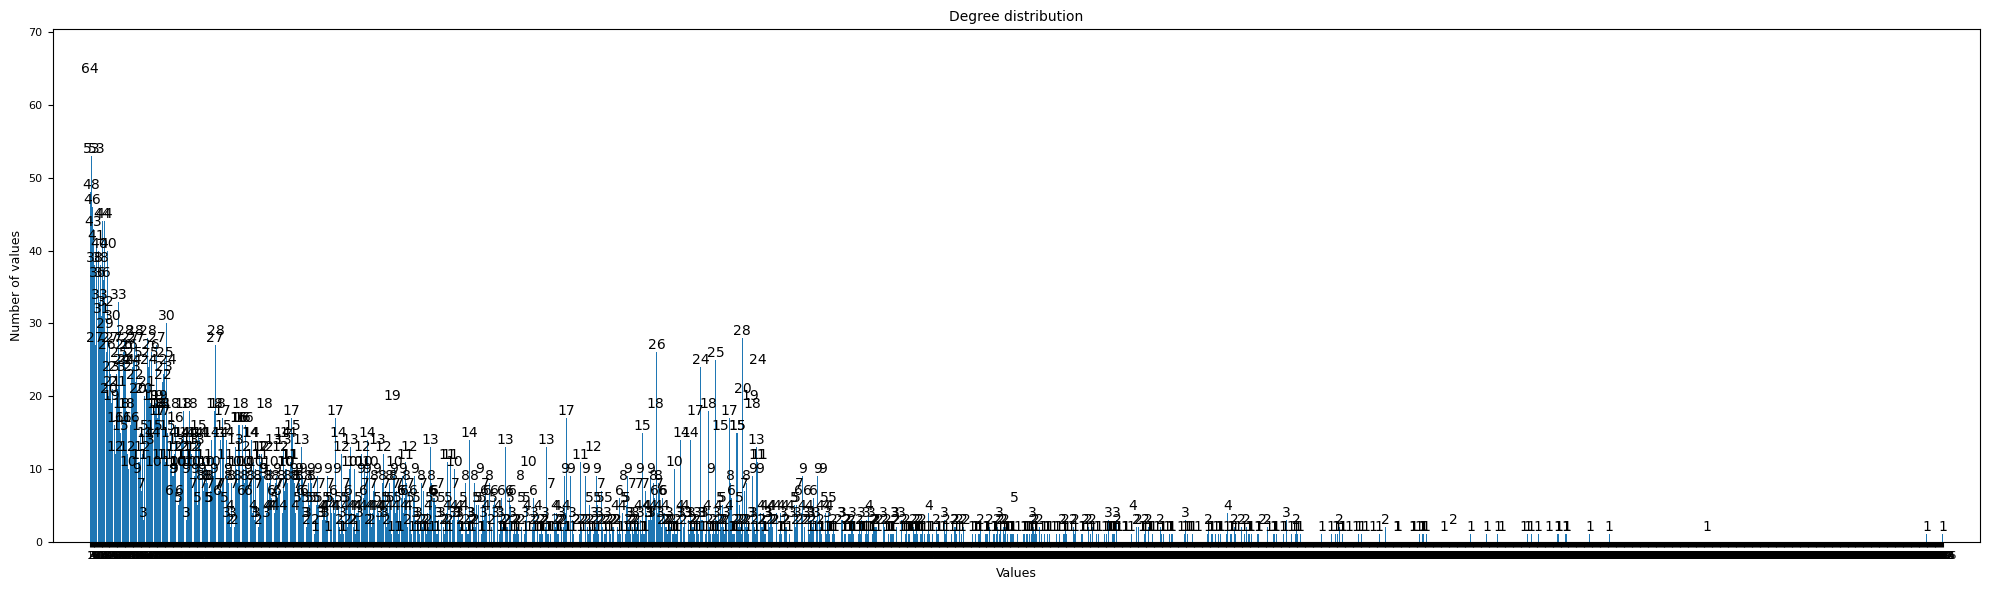

In [599]:
### Plot degree distribution
d = [d[1] for d in nx.degree(gu)]
naf.describe_plot_integers_distribution(d,'Degree distribution')

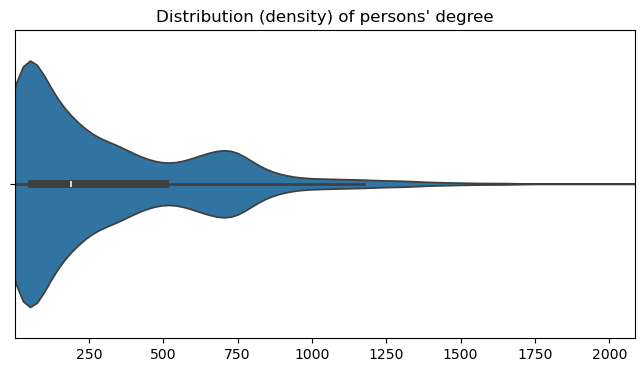

In [600]:
# Plot the distribution of de density

degree=[d[1] for d in nx.degree(gu)]

min_val = min(degree)
max_val = max(degree)

plt.figure(figsize=(8,4))
ax = sns.violinplot(data=degree, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of persons\' degree')
plt.show()

In [601]:
### Add eigenvector to nodes

## If error: PowerIterationFailedConvergence: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
# increase number of max iterations
eigenvector = nx.eigenvector_centrality(gu, max_iter=200)
nx.set_node_attributes(gu, eigenvector, 'eigenvector')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000193',
  {'coded_country': 'Germany',
   'degree': 227,
   'eigenvector': 0.0036263493977860385,
   'label': 'Hans Elsässer',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q100216',
  {'coded_country': 'Germany',
   'degree': 167,
   'eigenvector': 0.002454750045810116,
   'label': 'Willi Kalender',
   'periodsActivity': '1976-2000'})]


In [602]:
### Plot eigenvector density distribution 
eigenvector_s = pd.Series(list(eigenvector.values()))
stats = eigenvector_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    6434.00000000000000000000
mean        0.00728795710197926473
std         0.01011562620764398616
min         0.00000000000000140140
25%         0.00010012269631662761
50%         0.00157863646293273426
75%         0.01250907865690363031
max         0.05031296474823492015
dtype: object


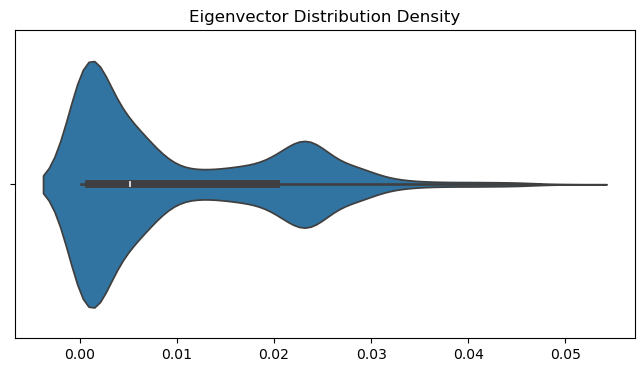

In [603]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=eigenvector_s[eigenvector_s> 0.00013610493515402787], orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

In [604]:
### Add betweenness to nodes
# Parameters for approximation: k=500, seed=42 and speed up

betweenness = nx.betweenness_centrality(gu, k=500, seed=42)
nx.set_node_attributes(gu, betweenness, 'betweenness')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000193',
  {'betweenness': 0.00016543318524425734,
   'coded_country': 'Germany',
   'degree': 227,
   'eigenvector': 0.0036263493977860385,
   'label': 'Hans Elsässer',
   'periodsActivity': '1951-1975'}),
 ('http://www.wikidata.org/entity/Q100216',
  {'betweenness': 1.3577394143133574e-05,
   'coded_country': 'Germany',
   'degree': 167,
   'eigenvector': 0.002454750045810116,
   'label': 'Willi Kalender',
   'periodsActivity': '1976-2000'})]


In [605]:
### Plot betweenness density distribution 
betweenness_s = pd.Series(list(betweenness.values()))
stats = betweenness_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    6434.00000000000000000000
mean        0.00032614698348766037
std         0.00079705032914435944
min         0.00000000000000000000
25%         0.00000641219499120199
50%         0.00005173981539101879
75%         0.00028450732051437907
max         0.01569447278057363102
dtype: object


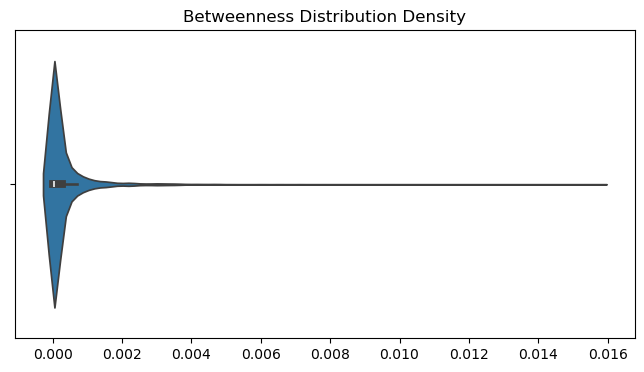

In [606]:
# Plot the distribution of eigenbetweenness vector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=betweenness_s, orient='h')
plt.title('Betweenness Distribution Density')
plt.show()

In [607]:
### Export node attributes to dataframe
nodes_data ={node: gu.nodes[node] for node in gu.nodes}
nodes_df_memb = pd.DataFrame(nodes_data).T
nodes_df_memb.reset_index(inplace=True)
nodes_df_memb.columns = ['personUri', 'label', 
                         'periodsActivity', 'coded_country',
                         'degree','eigenvector', 'betweenness']
nodes_df_memb.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1951-1975,Germany,227,0.003626,0.000165
1,http://www.wikidata.org/entity/Q100216,Willi Kalender,1976-2000,Germany,167,0.002455,0.000014


#### Explore eigenvector on gr_memb

In [608]:
nodes_df_memb.sort_values(by='eigenvector', ascending=False).iloc[:5]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
195,http://www.wikidata.org/entity/Q836911,Rashid Sunyaev,1976-2000,Russian Federation,2086,0.050313,0.007332
1125,http://www.wikidata.org/entity/Q335213,Martin Rees,1976-2000,United Kingdom,2068,0.05023,0.008458
1118,http://www.wikidata.org/entity/Q327196,Joseph Silk,1976-2000,United Kingdom,1623,0.047343,0.002319
1113,http://www.wikidata.org/entity/Q323320,Kip S. Thorne,1976-2000,United States Can.,1663,0.046989,0.003233
1007,http://www.wikidata.org/entity/Q233974,Jocelyn Bell Burnell,1976-2000,United Kingdom,1525,0.046469,0.001536


In [609]:
gr_memb_eigenv_1000=nodes_df_memb.sort_values(by='eigenvector', ascending=False).iloc[:1000]
gr_memb_eigenv_1000.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
195,http://www.wikidata.org/entity/Q836911,Rashid Sunyaev,1976-2000,Russian Federation,2086,0.050313,0.007332
1125,http://www.wikidata.org/entity/Q335213,Martin Rees,1976-2000,United Kingdom,2068,0.05023,0.008458


In [610]:
df=gr_memb_eigenv_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [611]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [612]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 106.36 , dof : 38
p-value : 0.0
Inertia (Phi-square):  0.106
Cramer:  0.231


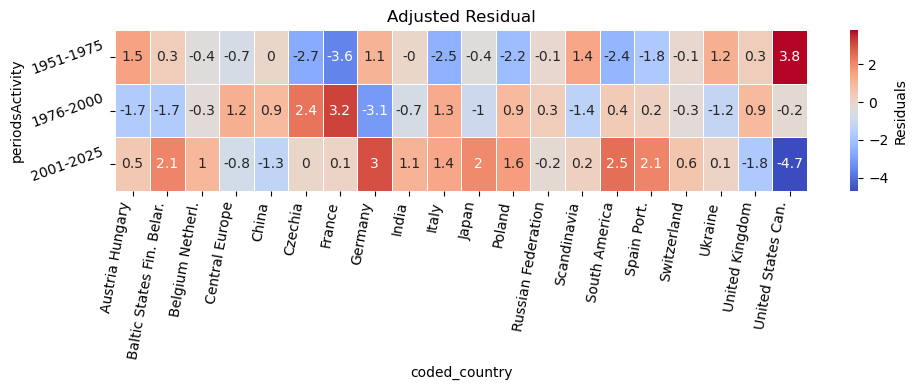

In [619]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 4))

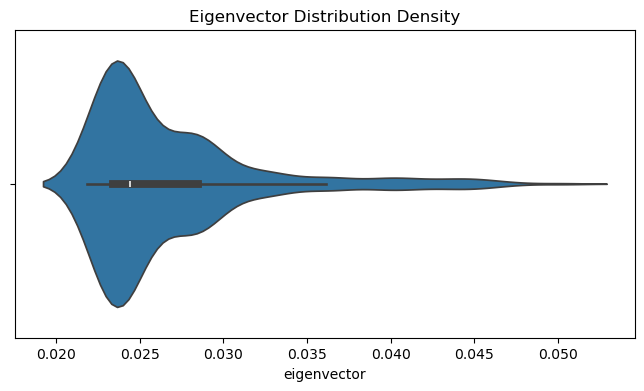

In [620]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_memb_eigenv_1000.eigenvector, orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

In [615]:
df_po.head(2)

,person_uri,organisation_uri,organisation_label,relationship
0,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q153978,University of Tübingen,education
1,http://www.wikidata.org/entity/Q1000193,http://www.wikidata.org/entity/Q543804,German Academy of Sciences Leopoldina,membership


In [616]:
sg1=gr_memb_eigenv_1000.merge(df_po[df_po['relationship']=='membership'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg1.sort_values(ascending=False)[:10])


organisation_label
International Astronomical Union         499
American Academy of Arts and Sciences    490
National Academy of Sciences             485
Royal Society                            139
American Philosophical Society           105
American Physical Society                102
Academia Europaea                         98
Russian Academy of Sciences               69
French Academy of Sciences                63
German Academy of Sciences Leopoldina     56
dtype: int64


In [617]:
nodes_df_memb.sort_values(by='eigenvector', ascending=False).iloc[:10]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
195,http://www.wikidata.org/entity/Q836911,Rashid Sunyaev,1976-2000,Russian Federation,2086,0.050313,0.007332
1125,http://www.wikidata.org/entity/Q335213,Martin Rees,1976-2000,United Kingdom,2068,0.05023,0.008458
1118,http://www.wikidata.org/entity/Q327196,Joseph Silk,1976-2000,United Kingdom,1623,0.047343,0.002319
1113,http://www.wikidata.org/entity/Q323320,Kip S. Thorne,1976-2000,United States Can.,1663,0.046989,0.003233
1007,http://www.wikidata.org/entity/Q233974,Jocelyn Bell Burnell,1976-2000,United Kingdom,1525,0.046469,0.001536
991,http://www.wikidata.org/entity/Q2161590,Roger Angel,1976-2000,United Kingdom,1497,0.04633,0.001553
1375,http://www.wikidata.org/entity/Q728331,Jim Peebles,1976-2000,United States Can.,1590,0.046156,0.002462
793,http://www.wikidata.org/entity/Q15453478,Péter Mészáros,1976-2000,Austria Hungary,1473,0.045635,0.001586
1084,http://www.wikidata.org/entity/Q2941858,Catherine Cesarsky,1976-2000,France,1711,0.045568,0.00339
705,http://www.wikidata.org/entity/Q123975,Michel Mayor,1976-2000,Switzerland,1459,0.045451,0.002789


#### Explore betweenness on gr_memb

In [621]:
nodes_df_memb.sort_values(by='betweenness', ascending=False).iloc[:5]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
1464,http://www.wikidata.org/entity/Q181369,Chen-ning Yang,1951-1975,China,1555,0.031925,0.015694
895,http://www.wikidata.org/entity/Q183279,Zhores Alferov,1951-1975,Baltic States Fin. Belar.,1236,0.026583,0.01011
85,http://www.wikidata.org/entity/Q183509,Ilya Prigogine,1951-1975,Russian Federation,1398,0.026651,0.010095
532,http://www.wikidata.org/entity/Q83331,Louis de Broglie,1926-1950,France,1013,0.008227,0.008546
207,http://www.wikidata.org/entity/Q907162,Vitalii Goldanskii,1951-1975,Baltic States Fin. Belar.,1619,0.032932,0.008471


In [622]:
gr_memb_betweenness_1000=nodes_df_memb.sort_values(by='betweenness', ascending=False).iloc[:1000]
gr_memb_betweenness_1000.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
1464,http://www.wikidata.org/entity/Q181369,Chen-ning Yang,1951-1975,China,1555,0.031925,0.015694
895,http://www.wikidata.org/entity/Q183279,Zhores Alferov,1951-1975,Baltic States Fin. Belar.,1236,0.026583,0.01011


In [623]:
df=gr_memb_betweenness_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [624]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [625]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 262.17 , dof : 133
p-value : 0.0
Inertia (Phi-square):  0.262
Cramer:  0.194


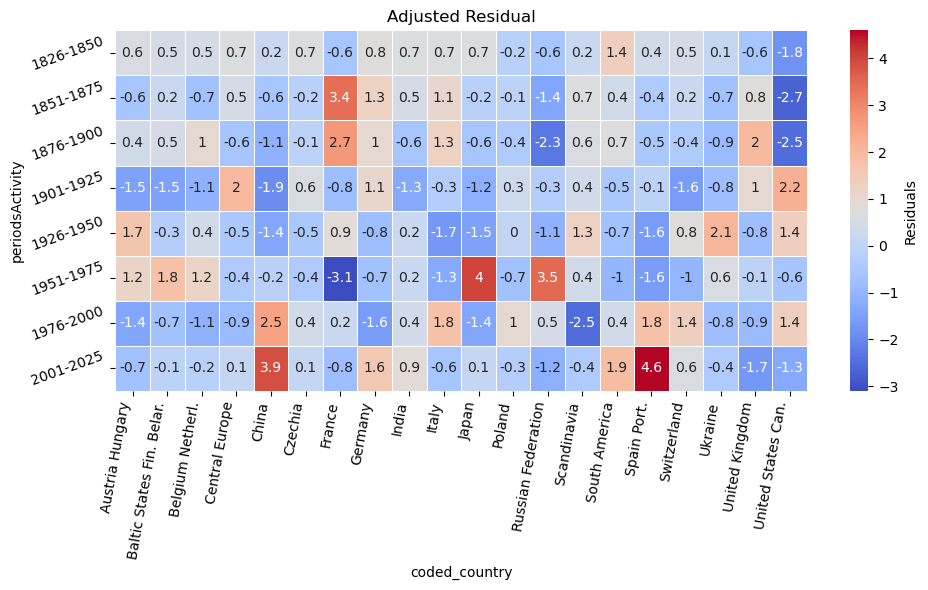

In [626]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 6))

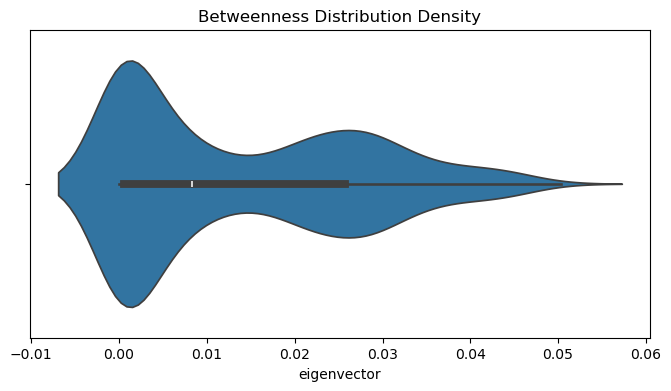

In [627]:
# Plot the distribution of betweenness density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_memb_betweenness_1000.eigenvector, orient='h')
plt.title('Betweenness Distribution Density')
plt.show()

In [646]:
sg1=pd.DataFrame(gr_memb_betweenness_1000.merge(df_po[df_po['relationship']=='membership'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size())
print(sg1.sort_values(by=0,ascending=False)[:15])


                                                      0
organisation_label                                     
American Academy of Arts and Sciences               514
National Academy of Sciences                        510
Royal Society                                       329
German Academy of Sciences Leopoldina               247
Russian Academy of Sciences                         228
American Philosophical Society                      228
Accademia Nazionale dei Lincei                      175
International Astronomical Union                    172
French Academy of Sciences                          151
Royal Swedish Academy of Sciences                   144
American Physical Society                           133
Academia Europaea                                   132
Göttingen Academy of Sciences and Humanities in...  132
Bavarian Academy of Sciences and Humanities         101
Royal Netherlands Academy of Arts and Sciences       99


In [636]:
sg1.head()

,0
organisation_label,
1874 Transit of Venus French Expedition to Japan,3
2nd State Duma of the Russian Federation,1
3rd State Duma of the Russian Federation,1
4th State Duma of the Russian Federation,1
5th State Duma of the Russian Federation,1


In [629]:
nodes_df_memb.sort_values(by='betweenness', ascending=False).iloc[:10]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
1464,http://www.wikidata.org/entity/Q181369,Chen-ning Yang,1951-1975,China,1555,0.031925,0.015694
895,http://www.wikidata.org/entity/Q183279,Zhores Alferov,1951-1975,Baltic States Fin. Belar.,1236,0.026583,0.01011
85,http://www.wikidata.org/entity/Q183509,Ilya Prigogine,1951-1975,Russian Federation,1398,0.026651,0.010095
532,http://www.wikidata.org/entity/Q83331,Louis de Broglie,1926-1950,France,1013,0.008227,0.008546
207,http://www.wikidata.org/entity/Q907162,Vitalii Goldanskii,1951-1975,Baltic States Fin. Belar.,1619,0.032932,0.008471
1125,http://www.wikidata.org/entity/Q335213,Martin Rees,1976-2000,United Kingdom,2068,0.05023,0.008458
498,http://www.wikidata.org/entity/Q7085,Niels Bohr,1926-1950,Scandinavia,906,0.004944,0.008233
231,http://www.wikidata.org/entity/Q103835,Peter Debye,1926-1950,Belgium Netherl.,837,0.004519,0.008081
163,http://www.wikidata.org/entity/Q65807,Reinhard Genzel,1976-2000,Germany,1654,0.041,0.007824
68,http://www.wikidata.org/entity/Q164396,Victor Ambartsumian,1951-1975,Russian Federation,1445,0.022929,0.007662


In [647]:
print(sg1.sort_values(by=0, ascending=False)[5:15].index.to_list())

['American Philosophical Society', 'Accademia Nazionale dei Lincei', 'International Astronomical Union', 'French Academy of Sciences', 'Royal Swedish Academy of Sciences', 'American Physical Society', 'Academia Europaea', 'Göttingen Academy of Sciences and Humanities in Lower Saxony', 'Bavarian Academy of Sciences and Humanities', 'Royal Netherlands Academy of Arts and Sciences']


In [649]:
l_persons=duckdb.query("""
    SELECT DISTINCT person_uri
    FROM df_rel, sg1
    WHERE organisation_label IN ('French Academy of Sciences', 'Royal Swedish Academy of Sciences', 
                       'Göttingen Academy of Sciences and Humanities in Lower Saxony', 
                       'Bavarian Academy of Sciences and Humanities', 'Royal Netherlands Academy of Arts and Sciences')
""").to_df()
print(len(l_persons))
l_persons.head(2)

1042


,person_uri
0,http://www.wikidata.org/entity/Q313512
1,http://www.wikidata.org/entity/Q1585


In [650]:
### Extract the subgraph using only the 1000 nodes
# .copy() creates a new independent graph object
sub_G = gu.subgraph(l_persons.person_uri.to_list()).copy()

# 4. Verify and Export
print(f"Subgraph nodes: {sub_G.number_of_nodes()}")
print(f"Subgraph edges: {sub_G.number_of_edges()}")

graph_address="da_graphs/subgraph_membership_betweenness.graphml"

# Export directly to Gephi format
nx.write_graphml(sub_G, graph_address)

Subgraph nodes: 1040
Subgraph edges: 65052
